In [1]:
#activate venv: 

import pandas as pd
import time
#other requirements: sklearn, matplotlib, statsmodels

In [2]:
start=time.perf_counter()

In [3]:
from DatabaseCreator import DatabaseCreator
import CJDH_local_settings
from FPLRunningAveragesCalculator import FPLRunningAveragesCalculator

current_season = 20252026
current_gw = 30 #predictions from gw+1

start=time.perf_counter()

if __name__ == "__main__":
    #Run Database Creator
    db_creator = DatabaseCreator(db_settings=CJDH_local_settings.local_settings['FPL_Points_Predictor'])
    fpl_engine = db_creator.get_engine_for("fpl_data_analysis")

    # Initialize the calculator
    calculator = FPLRunningAveragesCalculator(db_creator)
    
    # Define metrics to average
    metrics = [
        'minutes', 'total_points', 'team_elo', 'opp_team_elo',
        'goals_scored', 'bonus', 'bps', 'clean_sheets', 'goals_conceded',
        'expected_goals', 'expected_assists', 'expected_goal_involvements',
        'expected_goals_conceded', 'cbi', 'defensive_contribution',
        'recoveries', 'tackles', 'saves'
    ]
    
    # Define interaction pairs
    interaction_pairs = [
        ('expected_goal_involvements', 'defensive_contribution'),
    ]
    
    # Calculate running averages
    df = calculator.calculate(
        metrics_to_average=metrics,
        window_sizes=[3, 5, 10],
        include_alltime=True,
        include_per_90=True,
        include_raw=True,
        include_elo_adjusted=True,
        include_squared_per_90=True,
        interaction_pairs=interaction_pairs
    )

    # Identify columns to exclude from forward filling (all fpl playergwdf columns) real life data columns
    exclude_cols = ['player_name_id', 'season', 'event',
                    'fixture', 'total_points', 'minutes',
                    'goals_scored', 'assists', 'team_elo', 'opp_team_elo',
                    'position', 'bonus', 'bps', 'clean_sheets',
                    'goals_conceded', 'was_home', 'expected_assists',
                    'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded',
                    'starts', 'team_name', 'opp_team_name',
                    'cbi','defensive_contribution','recoveries','tackles'
                    'saves']

    # Create a mask for rows to fill: season 20252026 and event > 10
    mask = (df['season'] == current_season) & (df['event'] > current_gw)

    # Get columns to fill
    cols_to_fill = [col for col in df.columns if col not in exclude_cols]

    # Sort by player and event to ensure proper order
    df = df.sort_values(['season', 'player_name_id', 'event'])

    # Forward fill only for the masked rows
    df_filled = df.copy()

    for col in cols_to_fill:
        # Forward fill within each player group
        df_filled.loc[mask, col] = df_filled.groupby('player_name_id')[col].ffill()[mask]

    table_name = "playergw_transformed"
    db_creator.create_staging_table_then_insert_data(table_name, data=df_filled)
    playergw_transformed = db_creator.table_to_df(table_name=table_name)
    
    finish=time.perf_counter()
    print("playergw_transformed inserted into psql")
    print(f'Finished in {round(((finish-start)/60),2)} minute(s)')
    print(playergw_transformed.info())

playergw_transformed inserted into psql
Finished in 28.2 minute(s)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149259 entries, 0 to 149258
Columns: 431 entries, player_name_id to saves_elo_p90sq_10
dtypes: float64(426), object(5)
memory usage: 490.8+ MB
None


In [4]:
view = db_creator.run_sql("""SELECT
                        player_name_id, team_name, team_elo, season, event, opp_team_name, opp_team_elo, total_points, minutes, goals_scored
                            FROM playergw_transformed
                        WHERE season = 20252026 
                          AND event = 26 
                          AND player_name_id = 'Bukayo Saka'
                            """)
view

,player_name_id,team_name,team_elo,season,event,opp_team_name,opp_team_elo,total_points,minutes,goals_scored
0,Bukayo Saka,Arsenal,1249.67747,20252026.0,26.0,Brentford,1081.183298,1.0,20.0,0.0


In [5]:
from DatabaseCreator import DatabaseCreator
import CJDH_local_settings
from FPLPredictor import FPLPredictor

cbi_defcon_cols = [
    'cbi_at',
    'cbi_p90_at',
    'cbi_3',
    'cbi_p90_3',
    'cbi_elo_3',
    'cbi_elo_p90_3',
    'cbi_5',
    'cbi_p90_5',
    'cbi_elo_5',
    'cbi_elo_p90_5',
    'cbi_10',
    'cbi_p90_10',
    'cbi_elo_10',
    'cbi_elo_p90_10',
    'defensive_cont_at',
    'defensive_cont_p90_at',
    'defensive_cont_3',
    'defensive_cont_p90_3',
    'defensive_cont_elo_3',
    'defensive_cont_elo_p90_3',
    'defensive_cont_5',
    'defensive_cont_p90_5',
    'defensive_cont_elo_5',
    'defensive_cont_elo_p90_5',
    'defensive_cont_10',
    'defensive_cont_p90_10',
    'defensive_cont_elo_10',
    'defensive_cont_elo_p90_10',
    'saves_at',
    'saves_p90_at',
    'saves_3',
    'saves_p90_3',
    'saves_elo_3',
    'saves_elo_p90_3',
    'saves_5',
    'saves_p90_5',
    'saves_elo_5',
    'saves_elo_p90_5',
    'saves_10',
    'saves_p90_10',
    'saves_elo_10',
    'saves_elo_p90_10',
    'recoveries_at',
    'recoveries_p90_at',
    'recoveries_3',
    'recoveries_p90_3',
    'recoveries_elo_3',
    'recoveries_elo_p90_3',
    'recoveries_5',
    'recoveries_p90_5',
    'recoveries_elo_5',
    'recoveries_elo_p90_5',
    'recoveries_10',
    'recoveries_p90_10',
    'recoveries_elo_10',
    'recoveries_elo_p90_10',
    'tackles_at',
    'tackles_p90_at',
    'tackles_3',
    'tackles_p90_3',
    'tackles_elo_3',
    'tackles_elo_p90_3',
    'tackles_5',
    'tackles_p90_5',
    'tackles_elo_5',
    'tackles_elo_p90_5',
    'tackles_10',
    'tackles_p90_10',
    'tackles_elo_10',
    'tackles_elo_p90_10'
]

#Run Database Creator
if __name__ == "__main__":
    db_creator = DatabaseCreator(db_settings=CJDH_local_settings.local_settings['FPL_Points_Predictor'])
    fpl_engine = db_creator.get_engine_for("fpl_data_analysis")

    # Load df from sql
    df = db_creator.run_sql("""SELECT *
                            FROM playergw_transformed
                            """)
    print("=" * 80)
    print("Checking NaN Summary")
    print("=" * 80)

    temp_filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)
    temp_predictor = FPLPredictor(
        data=df[temp_filtered],
        target='expected_goals_per90',
        positions={'FWD', 'MID','DEF'},
        columns_to_drop=cbi_defcon_cols
    )
    nan_summary = temp_predictor.get_nan_summary()

Checking NaN Summary

NaN Summary for 288 potential features:
Total rows: 40906

Features with NaN values:
                                       feature  nan_count  nan_pct  non_null_count
                            recoveries_p90sq_3      35529    86.86            5377
                        recoveries_elo_p90sq_3      35529    86.86            5377
                               tackles_p90sq_3      35529    86.86            5377
                           tackles_elo_p90sq_3      35529    86.86            5377
                                   cbi_p90sq_3      35529    86.86            5377
                               cbi_elo_p90sq_3      35529    86.86            5377
                        defensive_cont_p90sq_3      35529    86.86            5377
                    defensive_cont_elo_p90sq_3      35529    86.86            5377
                               tackles_p90sq_5      35483    86.74            5423
                           tackles_elo_p90sq_5      35483    86

In [6]:
df[(df['season']==current_season)
   &(df['team_name']=='Arsenal')
   &(df['event']>20)
   &(df['player_name_id']=='Bukayo Saka')
   ][['player_name_id','event','total_points','opp_team_name','xgoals_p90sq_at']].sort_values(by='event')

,player_name_id,event,total_points,opp_team_name,xgoals_p90sq_at
132380,Bukayo Saka,21.0,3.0,Liverpool,0.364410
132382,Bukayo Saka,22.0,1.0,Nott'm Forest,0.361389
132384,Bukayo Saka,23.0,2.0,Man Utd,0.359322
132386,Bukayo Saka,24.0,0.0,Leeds,0.356240
132388,Bukayo Saka,25.0,0.0,Sunderland,0.356240
132314,Bukayo Saka,26.0,1.0,Brentford,0.356240
132316,Bukayo Saka,27.0,5.0,Spurs,0.353169
132390,Bukayo Saka,28.0,2.0,Chelsea,0.353025
132391,Bukayo Saka,29.0,9.0,Brighton,0.350034
132392,Bukayo Saka,30.0,3.0,Everton,0.347214


In [7]:
# #restricts to player_name_id who have >0 minutes in that season
# #model struggles to predict higher values, so maybe cut-off points at 10, or try log(points) as a depvar
# for each indepvar: filter outliers & standardize

In [8]:
# #Optimizing hyperparameters

# filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['expected_goals']>0)

# if __name__ == "__main__":

#     print("\n" + "=" * 80)
#     print("FWD xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)
    
#     FWD_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'FWD'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300]
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     FWD_xG_predictor.fit()
#     FWD_xG_predictor.plot_cv_results()
    
#     # Get best parameters in grid format
#     FWD_params_grid = FWD_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     FWD_xG_errors = FWD_xG_predictor.get_largest_errors(return_full_data=True)

#     print("\n" + "=" * 80)
#     print("MID xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)

#     MID_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'MID'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300] # cannot be larger than sample size!
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     MID_xG_predictor.fit()
#     MID_xG_predictor.plot_cv_results()

#     # Get best parameters in grid format
#     MID_params_grid = MID_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     MID_xG_errors = MID_xG_predictor.get_largest_errors(return_full_data=True)

#     print("\n" + "=" * 80)
#     print("DEF xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)

#     DEF_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'DEF'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300]
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     DEF_xG_predictor.fit()
#     DEF_xG_predictor.plot_cv_results()

#     # Get best parameters in grid format
#     DEF_params_grid = DEF_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     DEF_xG_errors = DEF_xG_predictor.get_largest_errors(return_full_data=True)


In [9]:
# print(FWD_params_grid)
# print(MID_params_grid)
# print(DEF_params_grid)

In [10]:
FWD_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}
MID_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}
DEF_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}

In [11]:
# target=expected_goals_per90, FWD_xG_predictor
# Cleaned df size: 2450/4170

# Performing GridSearchCV hyperparameter optimization...
# Parameter grid: {'n_estimators': [200], 'max_depth': [20, 30, 50], 'min_samples_split': [500]}
# Cross-validation folds: 5
# Fitting 5 folds for each of 3 candidates, totalling 15 fits

# Best parameters found:
#   max_depth: 20
#   min_samples_split: 500
#   n_estimators: 200

# Best CV RMSE: 0.4231

# Training Set Performance:
# R² Score: 0.1823
# RMSE: 0.4056
# MAE: 0.2978

# Test Set Performance:
# R² Score: 0.1273
# RMSE: 0.4301
# MAE: 0.3197

Cleaned df size: 2527/7584

Training Set Performance:
R² Score: 0.8399
RMSE: 13.1532
MAE: 10.8339

Test Set Performance:
R² Score: 0.3420
RMSE: 26.5421
MAE: 21.4789

Top 20 Feature Importances:
                feature  importance
              minutes_3    0.274350
   opp_team_elo_p90sq_3    0.052126
   opp_team_elo_p90sq_5    0.031355
       team_elo_p90sq_5    0.021649
      team_elo_p90sq_10    0.017164
       team_elo_p90sq_3    0.013024
      team_elo_p90sq_at    0.011249
  opp_team_elo_p90sq_at    0.010847
           bps_p90sq_at    0.010731
         opp_team_elo_5    0.009745
           opp_team_elo    0.009541
          minutes_elo_3    0.008715
               team_elo    0.008296
goals_conceded_p90sq_at    0.008269
  clean_sheets_p90sq_at    0.008185
        opp_team_elo_10    0.007882
  opp_team_elo_p90sq_10    0.007137
               elo_diff    0.006616
        goals_scored_10    0.006415
      xassists_p90sq_at    0.006288


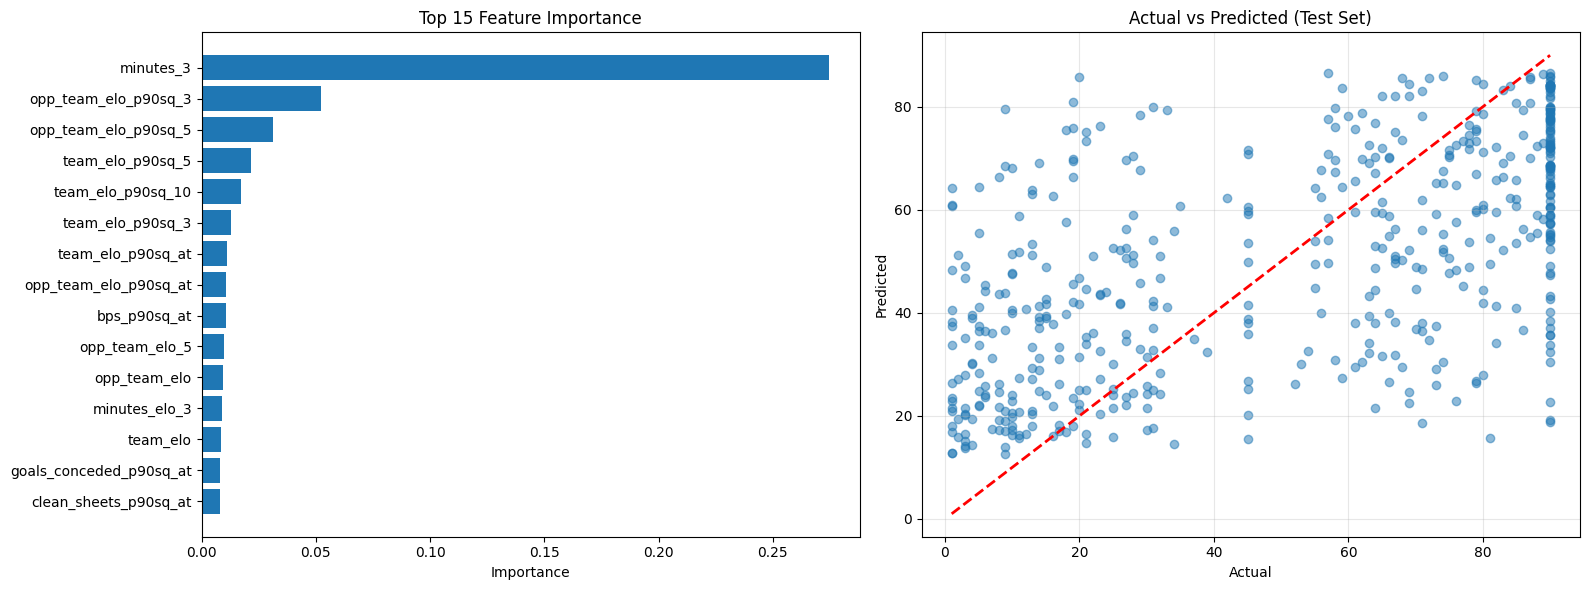

Cleaned df size: 8756/28309

Training Set Performance:
R² Score: 0.6676
RMSE: 18.5489
MAE: 15.2423

Test Set Performance:
R² Score: 0.3074
RMSE: 26.4124
MAE: 21.6769

Top 20 Feature Importances:
                feature  importance
              minutes_3    0.370104
   opp_team_elo_p90sq_3    0.028999
  opp_team_elo_p90sq_10    0.023901
                 bps_10    0.014183
          minutes_elo_3    0.011973
   opp_team_elo_p90sq_5    0.011329
        xg_over_g_ratio    0.009282
         minutes_elo_10    0.008647
             minutes_10    0.008149
           opp_team_elo    0.007927
      minutes_elo_p90_5    0.007664
                  bps_3    0.007392
  clean_sheets_p90sq_at    0.007272
        opp_team_elo_10    0.007165
         opp_team_elo_3    0.006805
  opp_team_elo_p90sq_at    0.006805
goals_conceded_p90sq_at    0.006567
  goals_conceded_elo_10    0.006474
         opp_team_elo_5    0.006140
 xgoals_conceded_elo_10    0.006038


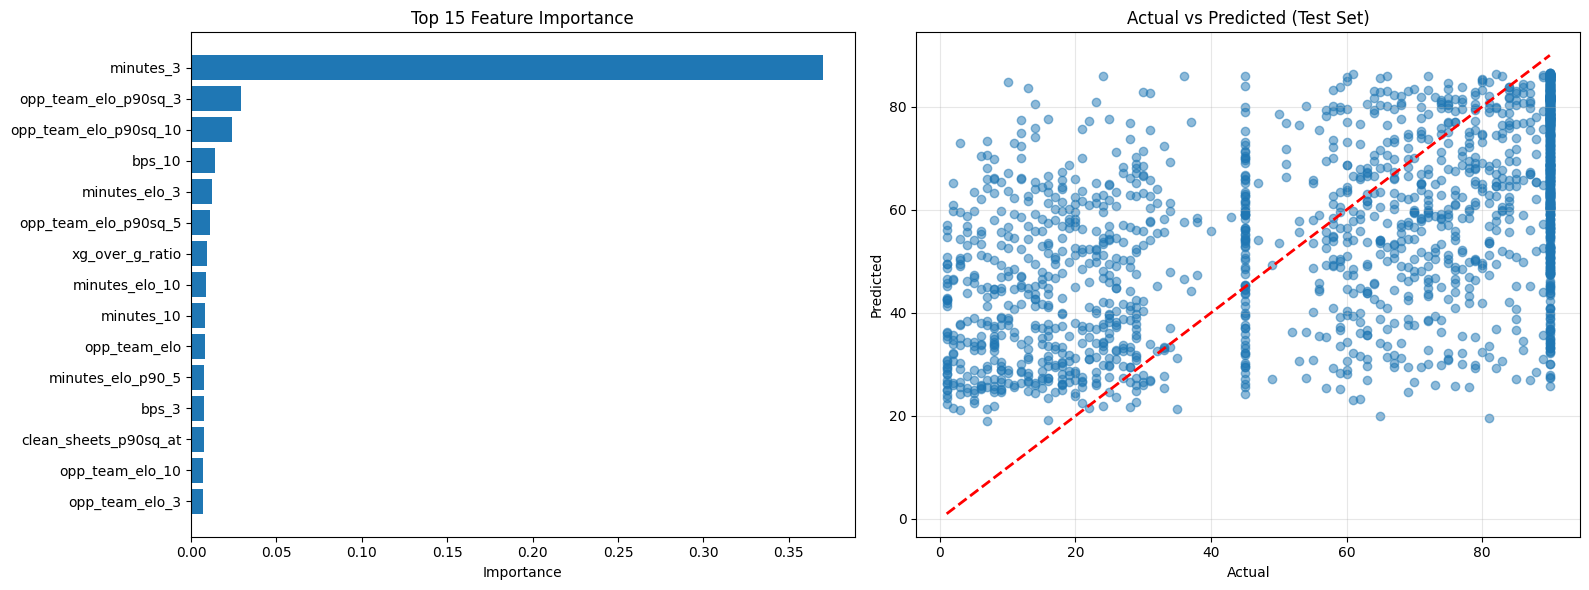

Cleaned df size: 5398/20407

Training Set Performance:
R² Score: 0.6786
RMSE: 16.5624
MAE: 12.2793

Test Set Performance:
R² Score: 0.1907
RMSE: 27.0059
MAE: 19.9526

Top 20 Feature Importances:
              feature  importance
            minutes_3    0.116775
 opp_team_elo_p90sq_3    0.093021
     team_elo_p90sq_3    0.037722
opp_team_elo_p90sq_10    0.020331
        minutes_elo_3    0.017665
    xassists_p90sq_at    0.012075
           minutes_10    0.011658
      xg_over_g_ratio    0.011656
      opp_team_elo_10    0.011288
    team_elo_p90sq_10    0.010808
             elo_diff    0.010335
         opp_team_elo    0.010021
       bonus_p90sq_at    0.009692
       opp_team_elo_5    0.009547
     team_elo_p90sq_5    0.009468
       opp_team_elo_3    0.008691
         bps_p90sq_at    0.008110
            minutes_5    0.008106
opp_team_elo_p90sq_at    0.007859
goals_scored_p90sq_at    0.007839


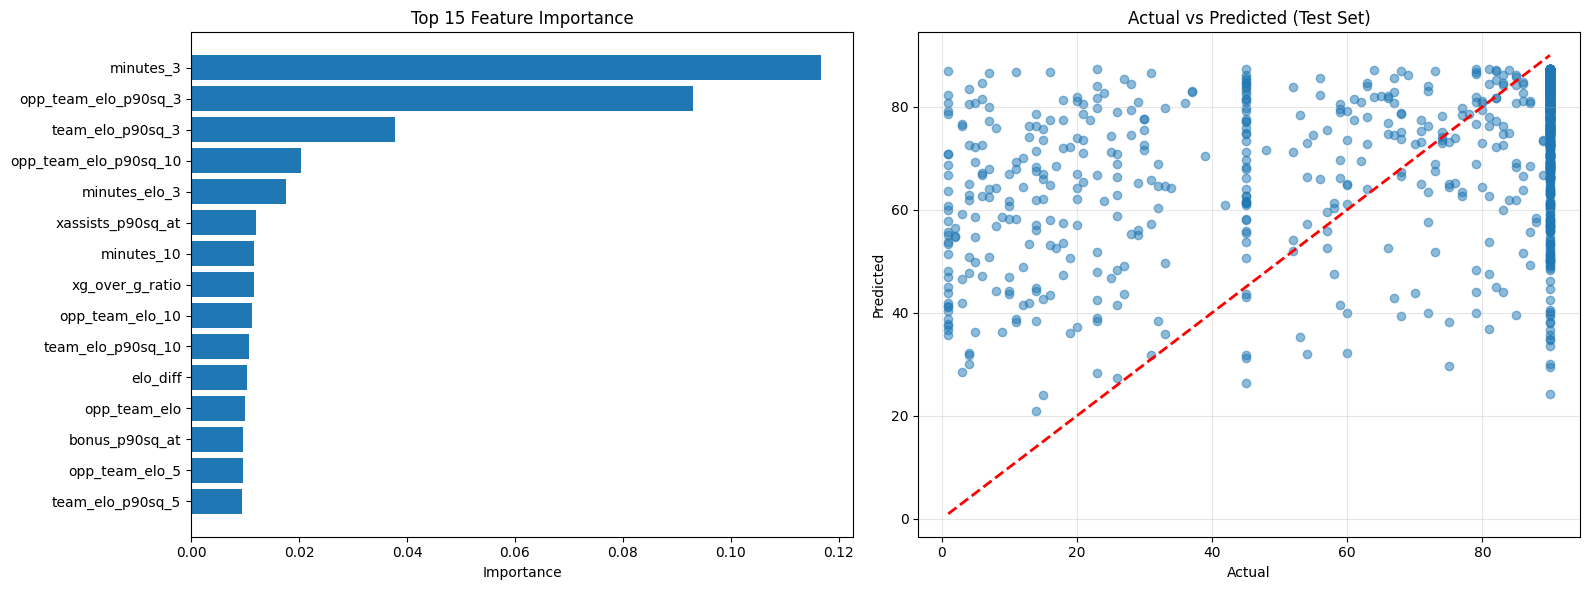

Cleaned df size: 3944/4211

Training Set Performance:
R² Score: 0.7551
RMSE: 2.5273
MAE: 0.5253

Test Set Performance:
R² Score: -0.0694
RMSE: 5.2854
MAE: 1.0825

Top 20 Feature Importances:
                    feature  importance
             team_elo_elo_3    0.052097
      opp_team_elo_p90sq_at    0.047669
             opp_team_elo_5    0.023877
                bps_p90sq_3    0.022270
               bps_p90sq_at    0.020581
             opp_team_elo_3    0.019470
          saves_elo_p90sq_3    0.018891
                     bps_10    0.017645
goals_conceded_elo_p90sq_10    0.017101
    goals_conceded_p90sq_at    0.016773
   opp_team_elo_elo_p90sq_3    0.015735
            opp_team_elo_10    0.015506
        minutes_elo_p90sq_3    0.015107
         opp_team_elo_elo_3    0.014252
          team_elo_p90sq_at    0.014206
              saves_p90sq_3    0.013605
               bps_p90sq_10    0.013275
              minutes_elo_3    0.012856
      total_points_p90sq_at    0.012815
      opp

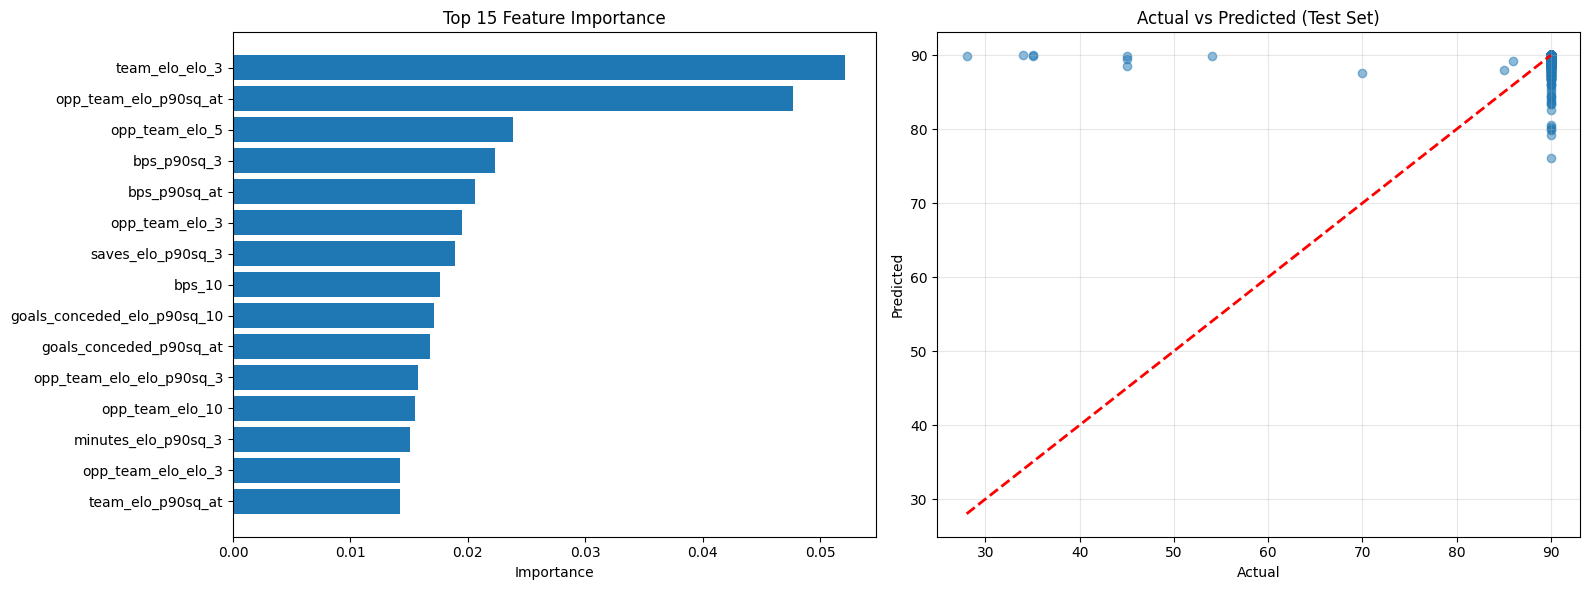

In [12]:
mins_filter = (df['player_season_minutes_total']>100)&(df['minutes']>0)

if __name__ == "__main__":
    
    FWD_mins_predictor = FPLPredictor(
                data=df[mins_filter],
        target='minutes',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=50
        )
    FWD_mins_predictor.fit()
    FWD_mins_predictor.plot_results()

    MID_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=50
        )
    MID_mins_predictor.fit()
    MID_mins_predictor.plot_results()

    DEF_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=50
        )
    DEF_mins_predictor.fit()
    DEF_mins_predictor.plot_results()

    GK_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10
        )
    GK_mins_predictor.fit()
    GK_mins_predictor.plot_results()

target=expected_goals_per90, FWD_xG_predictor
Cleaned df size: 2642/4355

Training Set Performance:
R² Score: 0.5792
RMSE: 0.2534
MAE: 0.2033

Test Set Performance:
R² Score: 0.0348
RMSE: 0.3736
MAE: 0.2848

Top 20 Feature Importances:
                  feature  importance
    goals_scored_p90sq_at    0.034092
                 elo_diff    0.033310
          xg_over_g_ratio    0.024935
           opp_team_elo_3    0.018597
           bonus_p90sq_at    0.017860
             opp_team_elo    0.016106
            minutes_elo_3    0.015333
     opp_team_elo_p90sq_3    0.014716
         team_elo_p90sq_3    0.014164
          opp_team_elo_10    0.014045
        minutes_elo_p90_3    0.013581
                 team_elo    0.012619
           opp_team_elo_5    0.012507
       total_points_elo_3    0.011863
               team_elo_5    0.011615
  goals_scored_elo_p90_10    0.010966
    opp_team_elo_p90sq_10    0.010414
              team_elo_10    0.010390
     opp_team_elo_p90sq_5    0.010281
tota

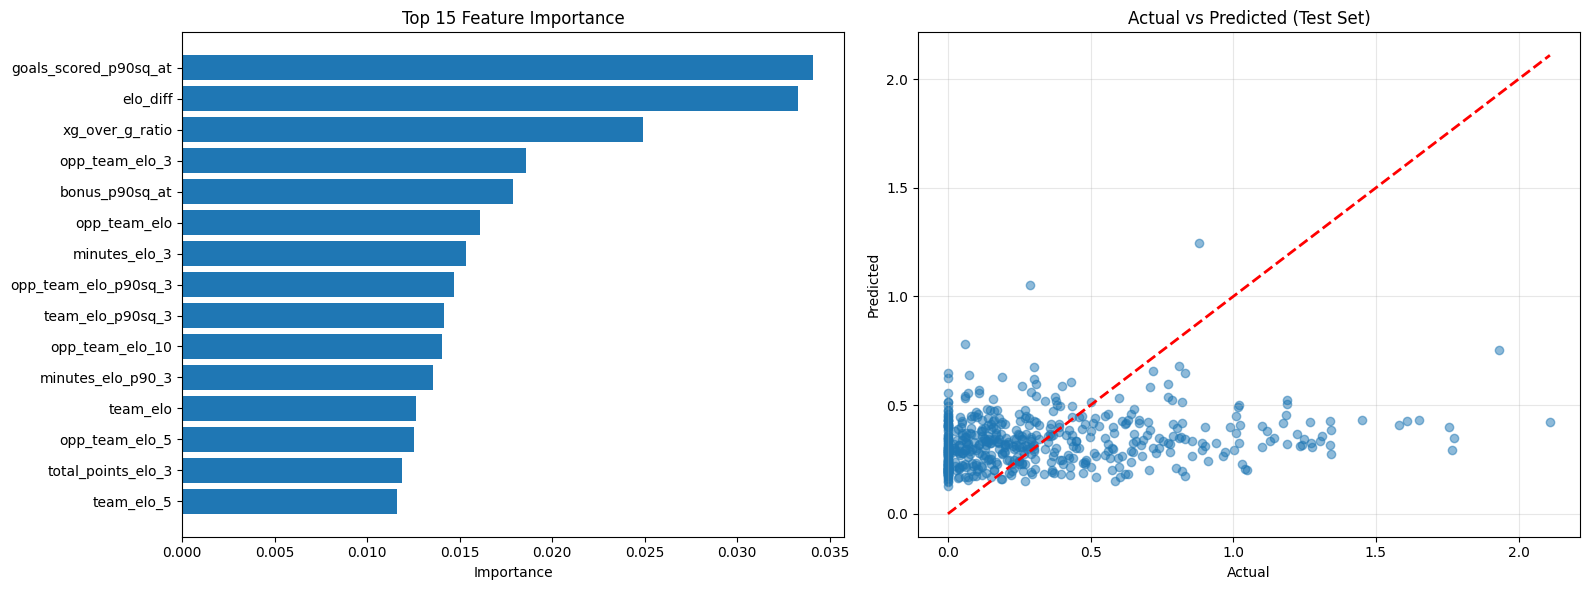

target=expected_goals_per90, MID_xG_predictor
Cleaned df size: 12189/18608

Training Set Performance:
R² Score: 0.3737
RMSE: 0.1742
MAE: 0.1179

Test Set Performance:
R² Score: 0.0860
RMSE: 0.2191
MAE: 0.1389

Top 20 Feature Importances:
                  feature  importance
    goals_scored_p90sq_at    0.157660
             opp_team_elo    0.035457
           bonus_p90sq_at    0.022579
          opp_team_elo_10    0.020305
             bps_p90sq_at    0.018223
                 elo_diff    0.018018
    clean_sheets_p90sq_at    0.015570
           opp_team_elo_5    0.014452
    opp_team_elo_p90sq_at    0.013764
         bps_elo_p90sq_10    0.012272
        team_elo_p90sq_at    0.011784
             bps_p90sq_10    0.010940
    total_points_p90sq_at    0.010462
           opp_team_elo_3    0.010244
  goals_conceded_p90sq_at    0.009201
 total_points_elo_p90sq_3    0.009004
    goals_conceded_elo_10    0.008913
      goals_scored_elo_10    0.008633
total_points_elo_p90sq_10    0.008610
  

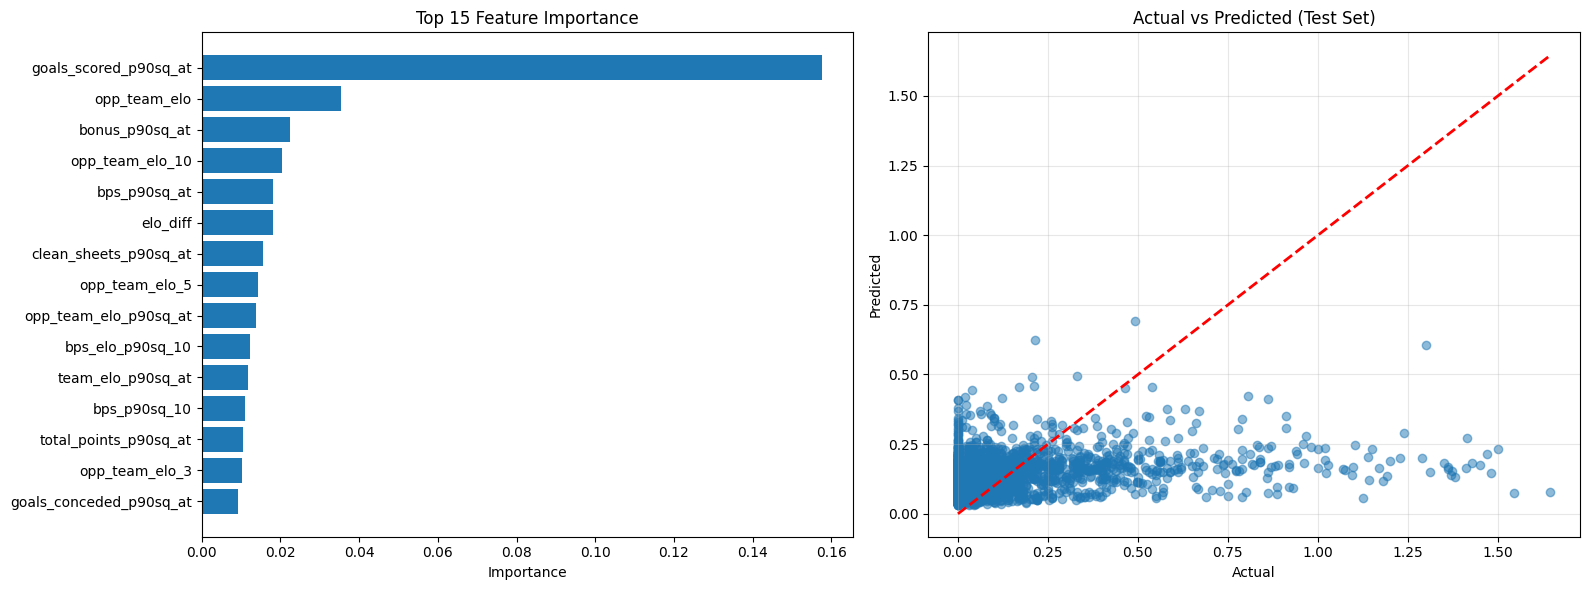

target=expected_goals_per90, DEF_xG_predictor
Cleaned df size: 10439/16647

Training Set Performance:
R² Score: 0.2823
RMSE: 0.0891
MAE: 0.0543

Test Set Performance:
R² Score: 0.0004
RMSE: 0.1120
MAE: 0.0614

Top 20 Feature Importances:
                  feature  importance
             opp_team_elo    0.041220
    goals_scored_p90sq_at    0.037211
           opp_team_elo_3    0.030369
                 elo_diff    0.023695
        team_elo_p90sq_at    0.019895
           opp_team_elo_5    0.017079
     opp_team_elo_p90sq_3    0.016624
  goals_conceded_p90sq_at    0.015508
    goals_conceded_elo_10    0.015460
             bps_p90sq_at    0.014444
       total_points_elo_5    0.014061
      goals_scored_elo_10    0.013490
 goals_conceded_elo_p90_5    0.011835
goals_conceded_elo_p90_10    0.011564
    total_points_p90sq_at    0.011365
               bps_elo_10    0.011304
    opp_team_elo_p90sq_at    0.011173
            minutes_elo_3    0.011104
total_points_elo_p90sq_10    0.010889
  

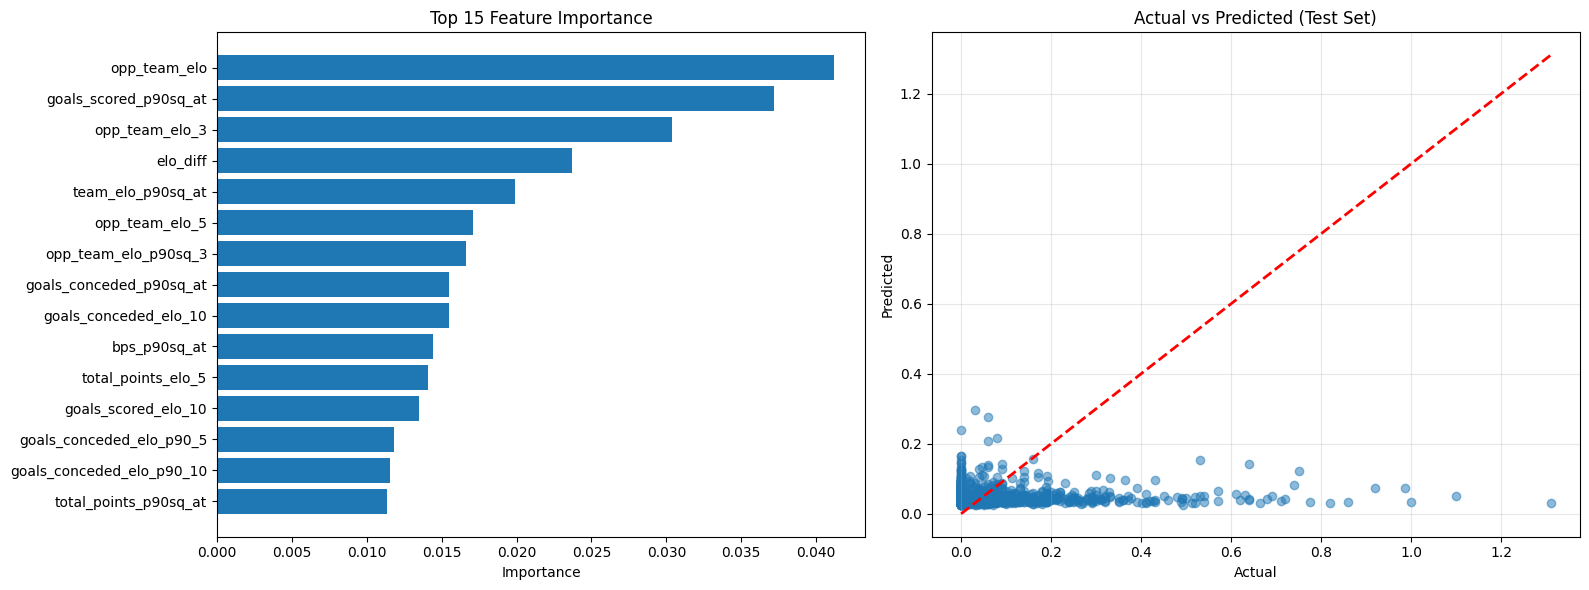

In [13]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)&(df['total_points']<12)

if __name__ == "__main__":
    
    print("target=expected_goals_per90, FWD_xG_predictor")
    FWD_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xG_predictor.fit()
    FWD_xG_predictor.plot_results()

    print("target=expected_goals_per90, MID_xG_predictor")
    MID_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xG_predictor.fit()
    MID_xG_predictor.plot_results()
    
    print("target=expected_goals_per90, DEF_xG_predictor")
    DEF_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xG_predictor.fit()
    DEF_xG_predictor.plot_results()

target=expected_assists_per90, FWD_xA_predictor
Cleaned df size: 2837/4640

Training Set Performance:
R² Score: 0.5498
RMSE: 0.0808
MAE: 0.0549

Test Set Performance:
R² Score: 0.0332
RMSE: 0.1181
MAE: 0.0725

Top 20 Feature Importances:
                feature  importance
      minutes_elo_p90_5    0.029664
         opp_team_elo_3    0.028731
           opp_team_elo    0.022629
               elo_diff    0.021884
        xg_over_g_ratio    0.019644
         opp_team_elo_5    0.019269
      minutes_elo_p90_3    0.017633
           bonus_elo_10    0.016428
   total_points_p90sq_3    0.015998
     minutes_elo_p90_10    0.014856
      team_elo_p90sq_at    0.013881
goals_conceded_p90sq_at    0.012851
opp_team_elo_elo_p90_10    0.012439
              bps_p90_3    0.012132
  opp_team_elo_p90sq_at    0.011599
         bonus_p90sq_at    0.010805
  clean_sheets_p90sq_10    0.010478
  goals_scored_p90sq_at    0.010373
 total_points_elo_p90_3    0.010368
 opp_team_elo_elo_p90_5    0.010340


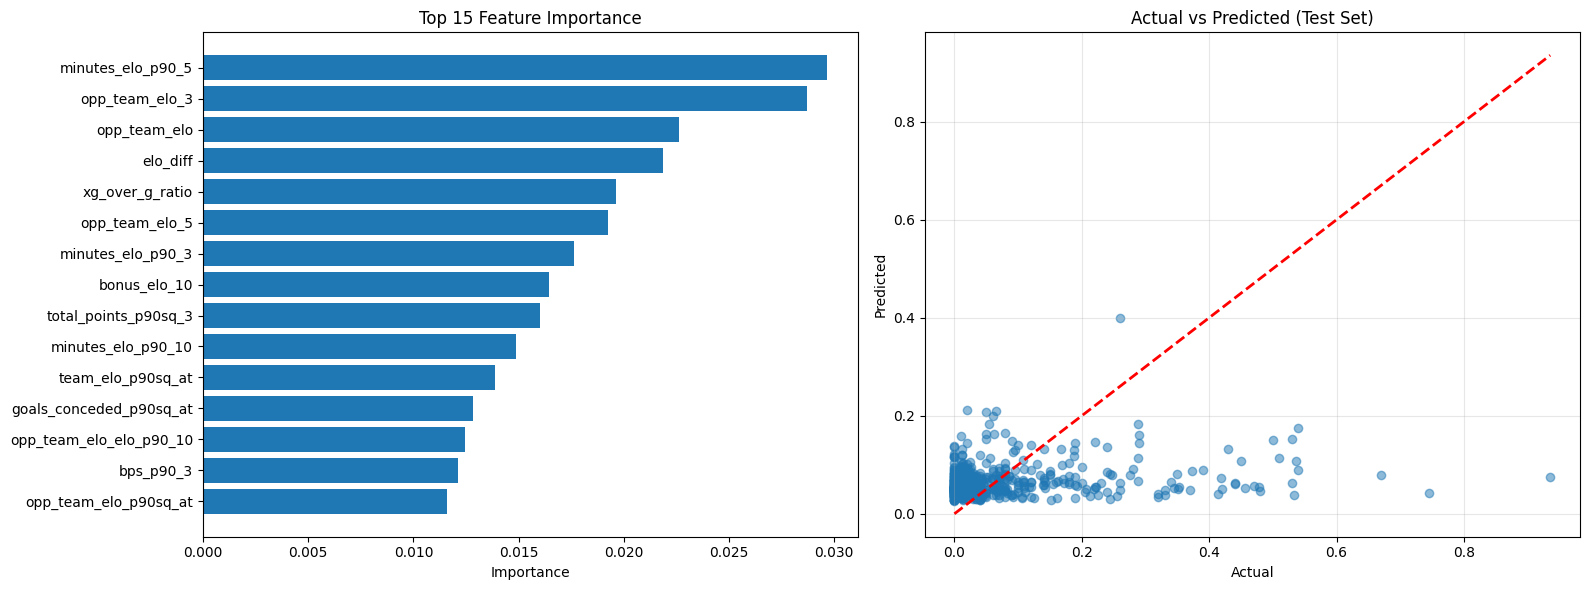

target=expected_assists_per90, MID_xA_predictor
Cleaned df size: 12621/19244

Training Set Performance:
R² Score: 0.4101
RMSE: 0.1251
MAE: 0.0889

Test Set Performance:
R² Score: 0.0579
RMSE: 0.1584
MAE: 0.1066

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.084782
         bonus_p90sq_at    0.077761
    total_points_elo_10    0.038817
           opp_team_elo    0.027068
             bps_elo_10    0.022861
  goals_scored_p90sq_at    0.018066
         opp_team_elo_5    0.017422
        opp_team_elo_10    0.016011
                 bps_10    0.013917
  clean_sheets_p90sq_at    0.012615
           bps_p90sq_at    0.012573
goals_conceded_p90sq_at    0.011662
  total_points_p90sq_at    0.010450
      team_elo_p90sq_at    0.009931
  opp_team_elo_p90sq_10    0.009539
          bps_elo_p90_5    0.009449
           bps_p90sq_10    0.009347
        total_points_10    0.009250
               team_elo    0.009126
                  bps_5    0.009042


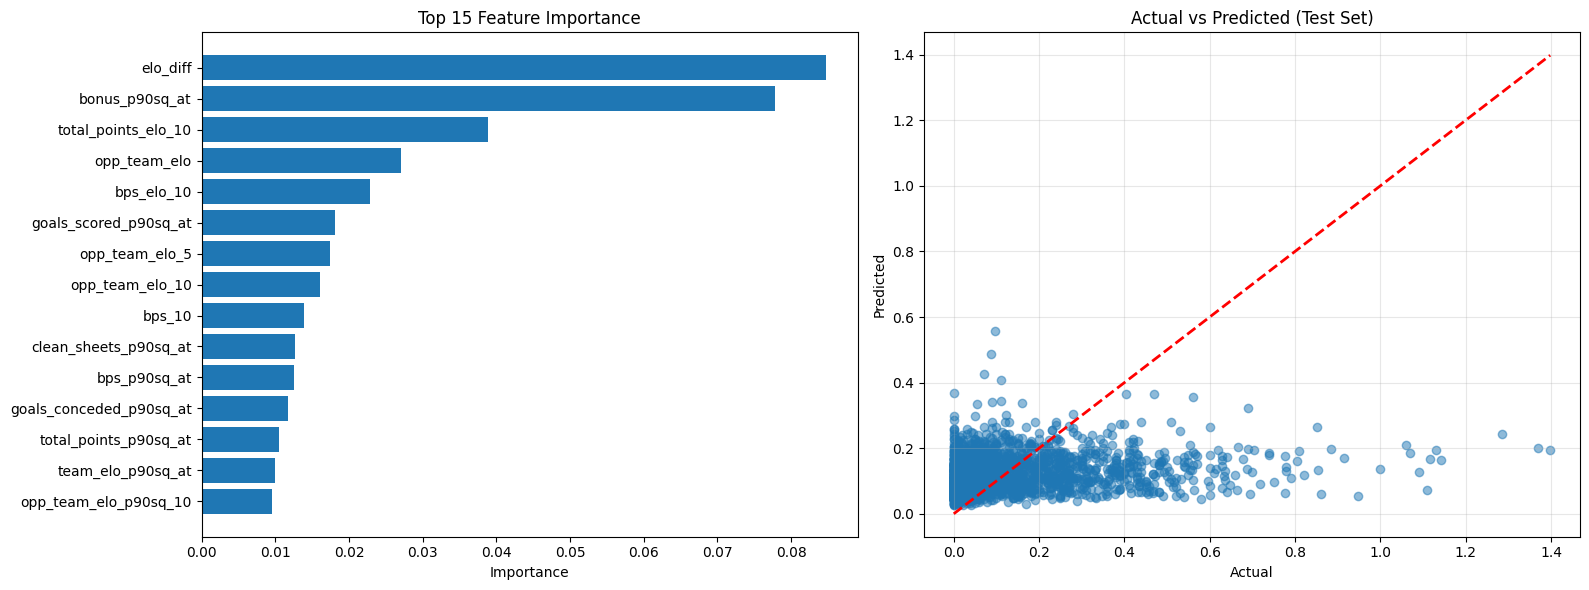

target=expected_assists_per90, DEF_xA_predictor
Cleaned df size: 10638/16971

Training Set Performance:
R² Score: 0.3797
RMSE: 0.0814
MAE: 0.0502

Test Set Performance:
R² Score: 0.0688
RMSE: 0.1053
MAE: 0.0596

Top 20 Feature Importances:
                 feature  importance
          bonus_p90sq_at    0.094892
                elo_diff    0.042940
            opp_team_elo    0.030165
                   bps_3    0.021275
 goals_conceded_p90sq_at    0.020563
   clean_sheets_p90sq_at    0.017635
   goals_scored_p90sq_at    0.016821
           bps_elo_p90_5    0.016201
            bps_p90sq_at    0.012782
   opp_team_elo_p90sq_at    0.012622
     minutes_elo_p90sq_3    0.011857
         opp_team_elo_10    0.011783
             bonus_elo_5    0.011604
       team_elo_p90sq_at    0.011529
  total_points_elo_p90_5    0.011180
                  bps_10    0.011051
          opp_team_elo_3    0.010909
clean_sheets_elo_p90sq_3    0.010620
   total_points_p90sq_at    0.010481
      minutes_elo_p9

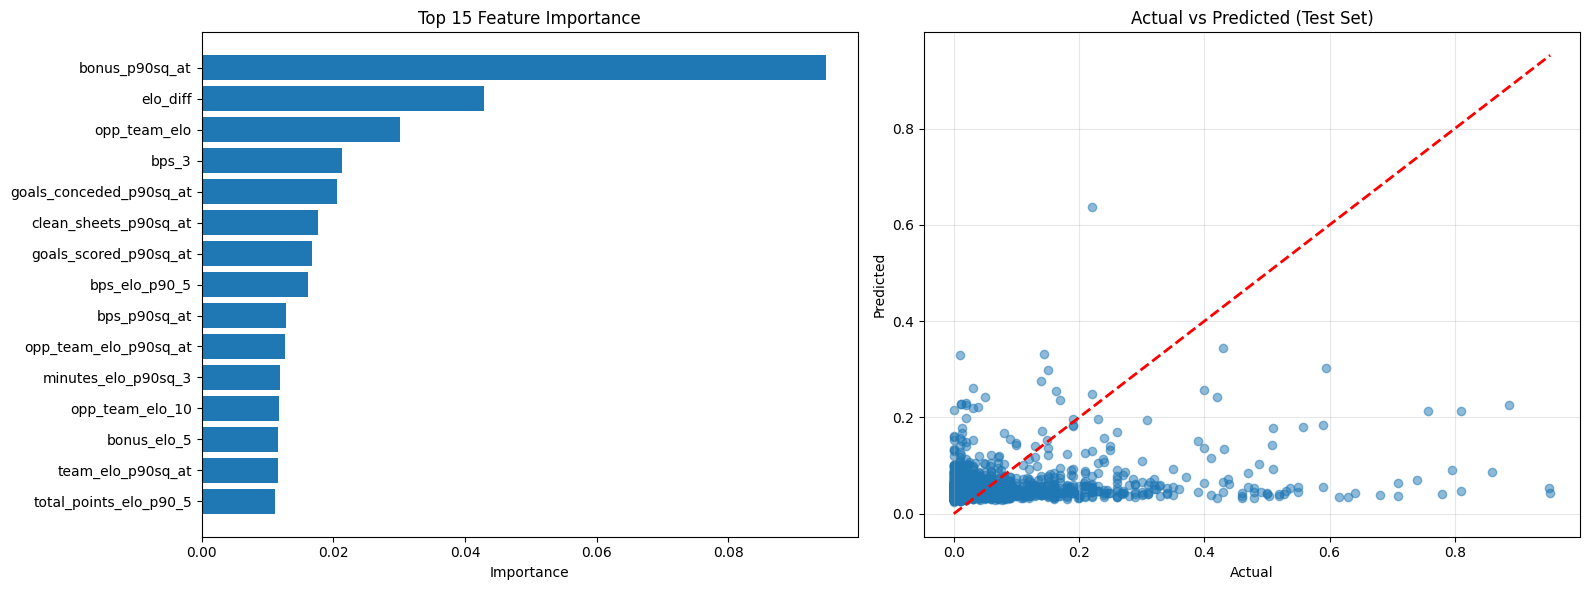

In [14]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_assists_per90, FWD_xA_predictor")
    FWD_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xA_predictor.fit()
    FWD_xA_predictor.plot_results()

    print("target=expected_assists_per90, MID_xA_predictor")
    MID_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xA_predictor.fit()
    MID_xA_predictor.plot_results()
    
    print("target=expected_assists_per90, DEF_xA_predictor")
    DEF_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xA_predictor.fit()
    DEF_xA_predictor.plot_results()

target=expected_goals_conceded_per90, FWD_xGC_predictor
Cleaned df size: 2837/4640

Training Set Performance:
R² Score: 0.6427
RMSE: 0.5500
MAE: 0.4447

Test Set Performance:
R² Score: 0.1446
RMSE: 0.8787
MAE: 0.6691

Top 20 Feature Importances:
                    feature  importance
                   elo_diff    0.157523
               opp_team_elo    0.045446
            xg_over_g_ratio    0.042264
      clean_sheets_p90sq_at    0.020679
            opp_team_elo_10    0.017398
    goals_conceded_p90sq_at    0.015061
             opp_team_elo_5    0.014715
         minutes_elo_p90_10    0.013110
       goals_conceded_elo_5    0.012971
          team_elo_p90sq_at    0.011248
             opp_team_elo_3    0.010057
       total_points_p90sq_5    0.008804
goals_conceded_elo_p90sq_10    0.008771
      goals_scored_p90sq_at    0.008321
      goals_conceded_elo_10    0.008250
             team_elo_elo_5    0.008149
                 minutes_10    0.007914
 goals_conceded_elo_p90sq_5    0.0

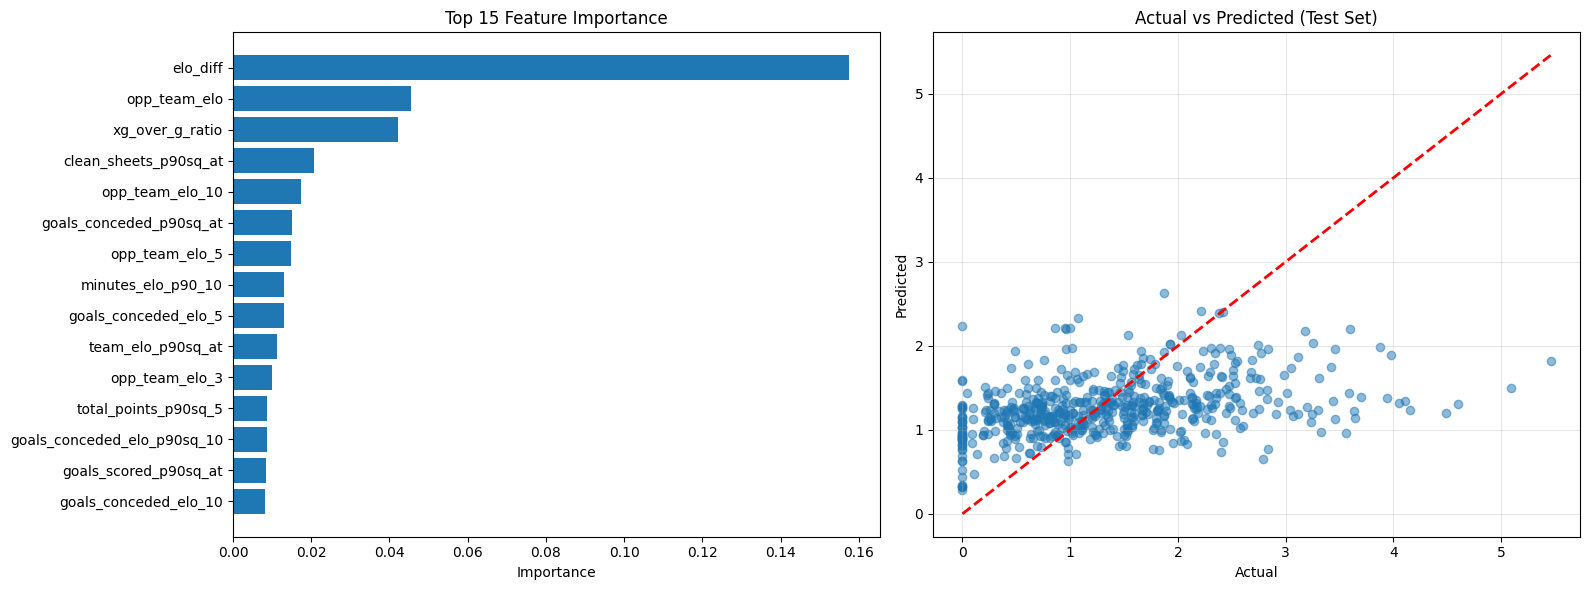

target=expected_goals_conceded_per90, MID_xGC_predictor
Cleaned df size: 12621/19244

Training Set Performance:
R² Score: 0.5437
RMSE: 0.6277
MAE: 0.4988

Test Set Performance:
R² Score: 0.3154
RMSE: 0.7838
MAE: 0.6107

Top 20 Feature Importances:
              feature  importance
             elo_diff    0.248232
         opp_team_elo    0.076764
      opp_team_elo_10    0.035403
       opp_team_elo_5    0.035224
             team_elo    0.024419
           team_elo_5    0.023720
       opp_team_elo_3    0.023672
          team_elo_10    0.022648
           team_elo_3    0.021649
       team_elo_elo_3    0.017607
   opp_team_elo_elo_3    0.016090
       team_elo_elo_5    0.014832
    minutes_elo_p90_3    0.014428
   opp_team_elo_elo_5    0.014353
  minutes_elo_p90sq_3    0.012968
clean_sheets_p90sq_at    0.011766
  opp_team_elo_elo_10    0.011166
      team_elo_elo_10    0.010466
 goals_conceded_elo_5    0.009577
 minutes_elo_p90sq_10    0.008421


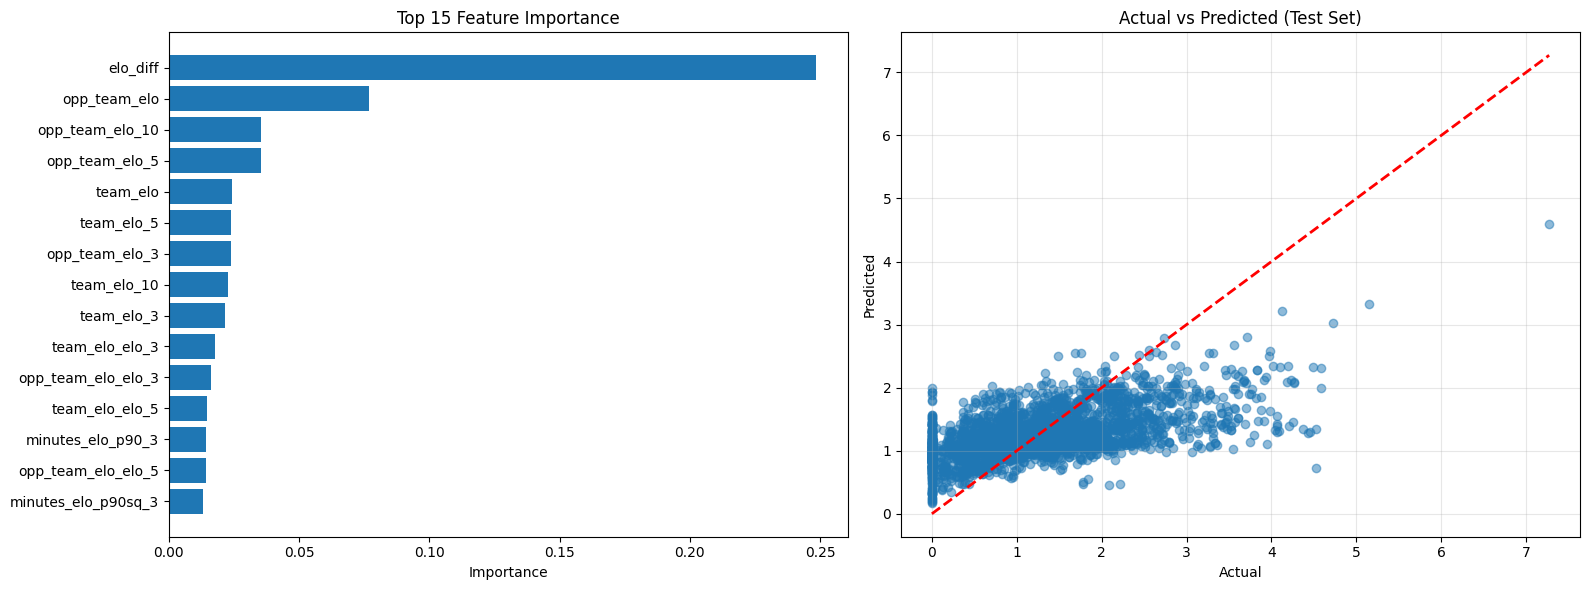

target=expected_goals_conceded_per90, DEF_xGC_predictor
Cleaned df size: 10638/16971

Training Set Performance:
R² Score: 0.5710
RMSE: 0.6094
MAE: 0.4853

Test Set Performance:
R² Score: 0.2963
RMSE: 0.7897
MAE: 0.6047

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.219227
           opp_team_elo    0.076836
        opp_team_elo_10    0.032256
         opp_team_elo_5    0.031197
    opp_team_elo_elo_10    0.022558
         opp_team_elo_3    0.020222
             team_elo_5    0.019366
               team_elo    0.019184
  clean_sheets_p90sq_at    0.019125
            team_elo_10    0.018580
     opp_team_elo_elo_3    0.017233
         team_elo_elo_3    0.016907
      minutes_elo_p90_3    0.016186
             team_elo_3    0.015971
goals_conceded_p90sq_at    0.015223
    minutes_elo_p90sq_3    0.014139
         team_elo_elo_5    0.013335
     opp_team_elo_elo_5    0.010664
        team_elo_elo_10    0.010282
  opp_team_elo_p90sq_at    0.009

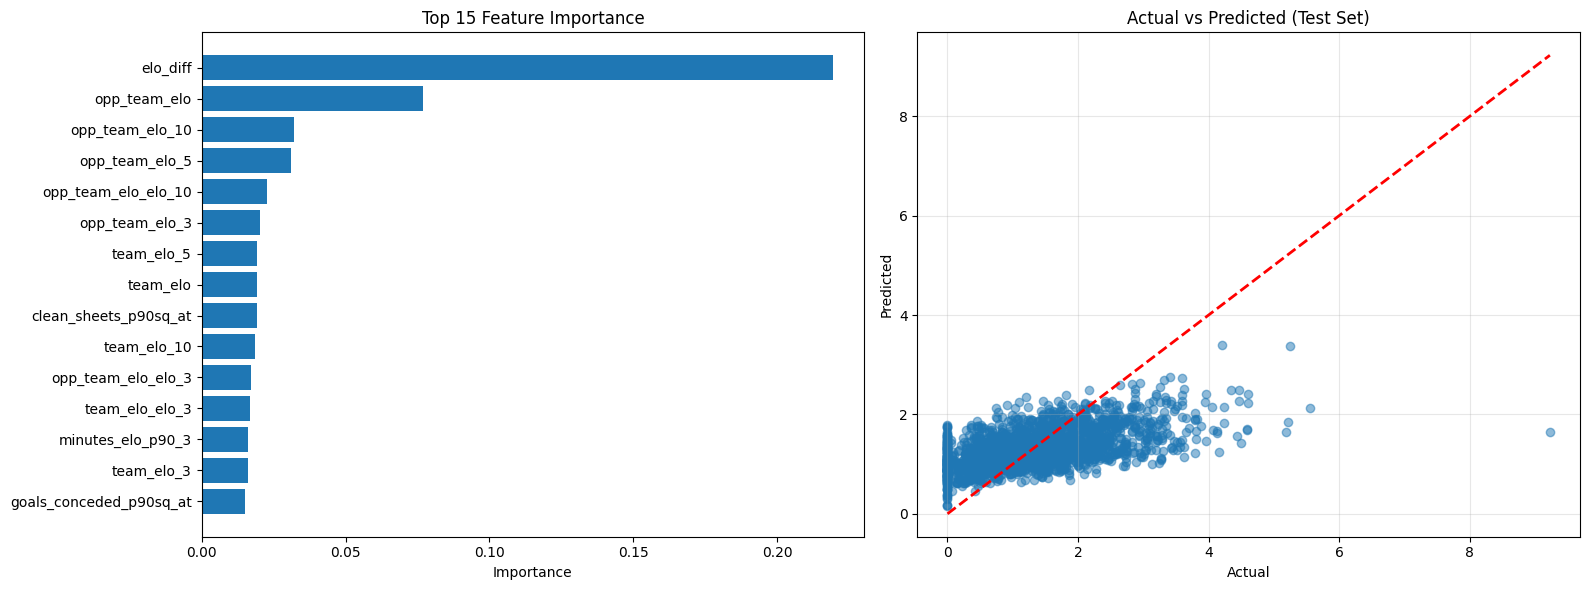

target=expected_goals_conceded_per90, GK_xGC_predictor
Cleaned df size: 2609/4149

Training Set Performance:
R² Score: 0.6890
RMSE: 0.5140
MAE: 0.4152

Test Set Performance:
R² Score: 0.1262
RMSE: 0.8413
MAE: 0.6602

Top 20 Feature Importances:
                    feature  importance
                   elo_diff    0.166929
               opp_team_elo    0.049553
      opp_team_elo_p90sq_at    0.030091
    goals_conceded_p90sq_at    0.023350
             saves_p90sq_at    0.022918
      opp_team_elo_p90sq_10    0.022199
          team_elo_p90sq_at    0.019204
            opp_team_elo_10    0.018028
         saves_elo_p90sq_10    0.015133
          saves_elo_p90sq_3    0.013362
             opp_team_elo_5    0.013147
      clean_sheets_p90sq_at    0.012567
      total_points_p90sq_at    0.012050
               bps_p90sq_at    0.012005
             saves_p90sq_10    0.011891
             bonus_p90sq_at    0.010936
       opp_team_elo_p90sq_5    0.010915
          saves_elo_p90sq_5    0.01

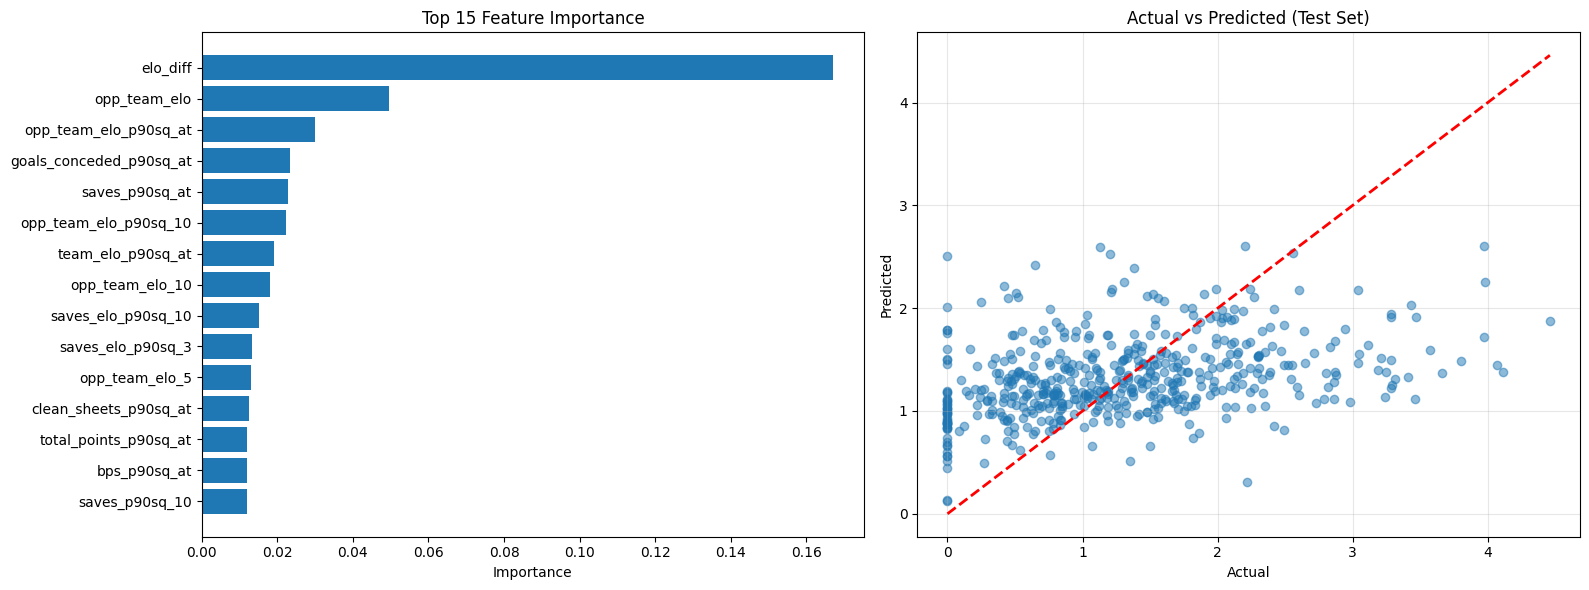

In [15]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_goals_conceded_per90, FWD_xGC_predictor")
    FWD_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xGC_predictor.fit()
    FWD_xGC_predictor.plot_results()

    print("target=expected_goals_conceded_per90, MID_xGC_predictor")
    MID_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xGC_predictor.fit()
    MID_xGC_predictor.plot_results()
    
    print("target=expected_goals_conceded_per90, DEF_xGC_predictor")
    DEF_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xGC_predictor.fit()
    DEF_xGC_predictor.plot_results()

    print("target=expected_goals_conceded_per90, GK_xGC_predictor")
    GK_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10)
    GK_xGC_predictor.fit()
    GK_xGC_predictor.plot_results()

target=bps_per90, FWD_bps_predictor
Cleaned df size: 4149/4640

Training Set Performance:
R² Score: 0.4796
RMSE: 13.4556
MAE: 10.9240

Test Set Performance:
R² Score: 0.0043
RMSE: 17.8006
MAE: 14.0541

Top 20 Feature Importances:
                  feature  importance
                 elo_diff    0.073467
             opp_team_elo    0.035547
       opp_team_elo_elo_5    0.021133
  goals_conceded_p90sq_at    0.016996
      minutes_elo_p90sq_5    0.016729
clean_sheets_elo_p90sq_10    0.015880
           bonus_p90sq_at    0.015658
        minutes_elo_p90_3    0.014852
           opp_team_elo_3    0.013572
           opp_team_elo_5    0.013507
             bps_p90sq_at    0.012062
        minutes_elo_p90_5    0.011858
    clean_sheets_p90sq_at    0.011845
     minutes_elo_p90sq_10    0.011752
          opp_team_elo_10    0.011590
    opp_team_elo_p90sq_at    0.010557
                bps_elo_3    0.009627
    total_points_p90sq_at    0.009128
     goals_conceded_elo_5    0.008988
      minu

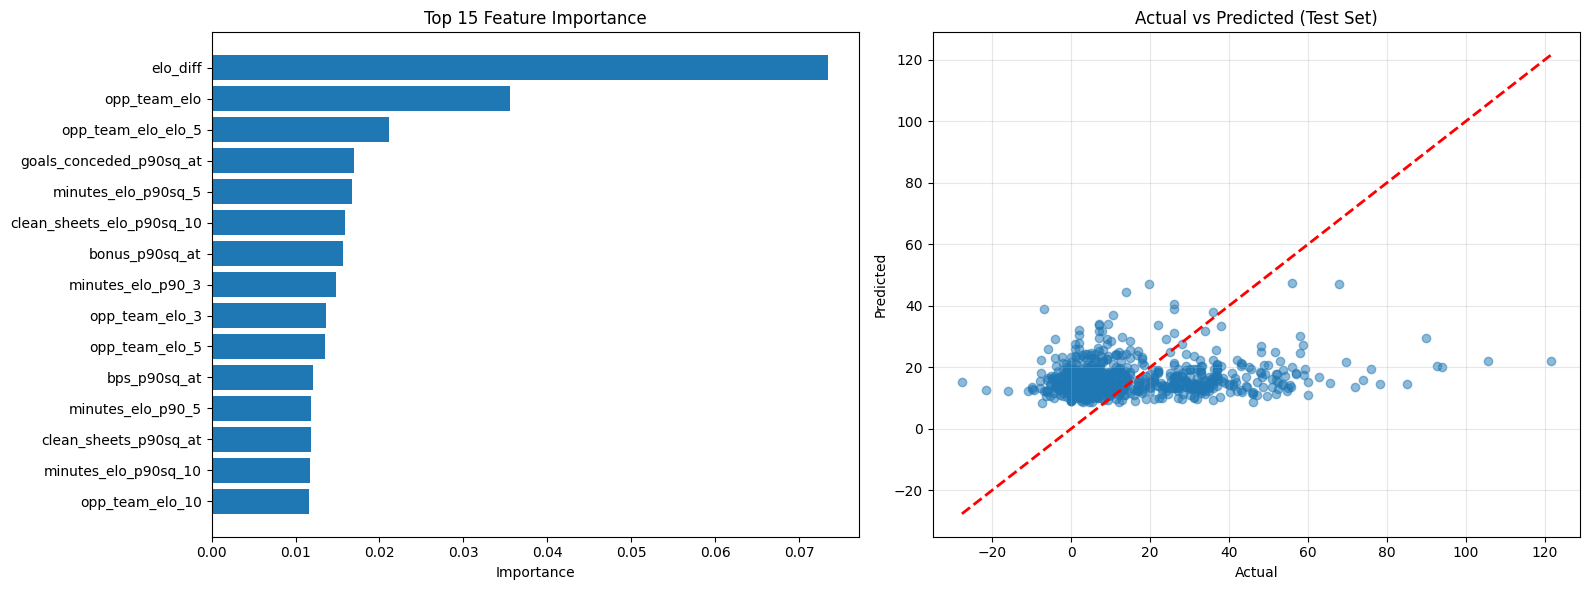

target=bps_per90, MID_bps_predictor
Cleaned df size: 18635/19244

Training Set Performance:
R² Score: 0.3124
RMSE: 9.4836
MAE: 7.2084

Test Set Performance:
R² Score: 0.0578
RMSE: 11.2084
MAE: 8.1168

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.131325
             bps_elo_10    0.034647
                 bps_10    0.028361
           opp_team_elo    0.020639
        opp_team_elo_10    0.019441
         bonus_p90sq_at    0.019262
                  bps_5    0.017189
         opp_team_elo_3    0.013027
  goals_scored_p90sq_at    0.012443
         opp_team_elo_5    0.011275
      team_elo_p90sq_at    0.011107
    total_points_elo_10    0.010216
           bps_p90sq_at    0.009975
  clean_sheets_p90sq_at    0.009865
  total_points_p90sq_at    0.009285
goals_conceded_p90sq_at    0.009276
            bps_p90sq_5    0.008676
  opp_team_elo_p90sq_at    0.008490
              bps_elo_5    0.008330
         minutes_elo_10    0.008217


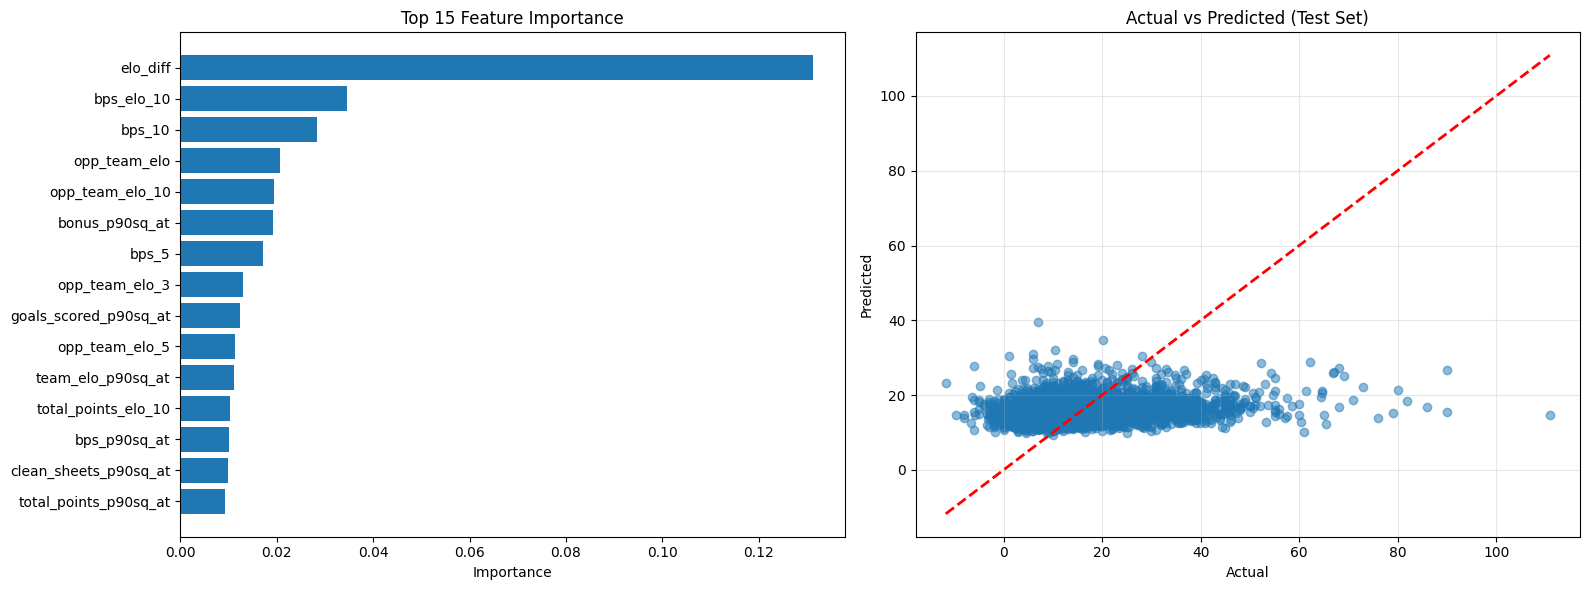

target=bps_per90, DEF_bps_predictor
Cleaned df size: 15965/16971

Training Set Performance:
R² Score: 0.4145
RMSE: 7.5714
MAE: 6.0602

Test Set Performance:
R² Score: 0.1415
RMSE: 9.1841
MAE: 7.2332

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.238656
           opp_team_elo    0.031582
        opp_team_elo_10    0.027768
         opp_team_elo_5    0.020123
         opp_team_elo_3    0.019096
             bps_p90_10    0.014490
         bonus_p90sq_at    0.014131
            team_elo_10    0.013186
goals_conceded_p90sq_at    0.011837
            bps_p90sq_5    0.010084
               team_elo    0.009492
         bps_elo_p90_10    0.009425
  clean_sheets_p90sq_at    0.008952
                 bps_10    0.008941
             team_elo_5    0.008749
              bps_p90_5    0.008710
  opp_team_elo_p90sq_at    0.008691
           bps_p90sq_10    0.008564
       bps_elo_p90sq_10    0.008444
  goals_scored_p90sq_at    0.008260


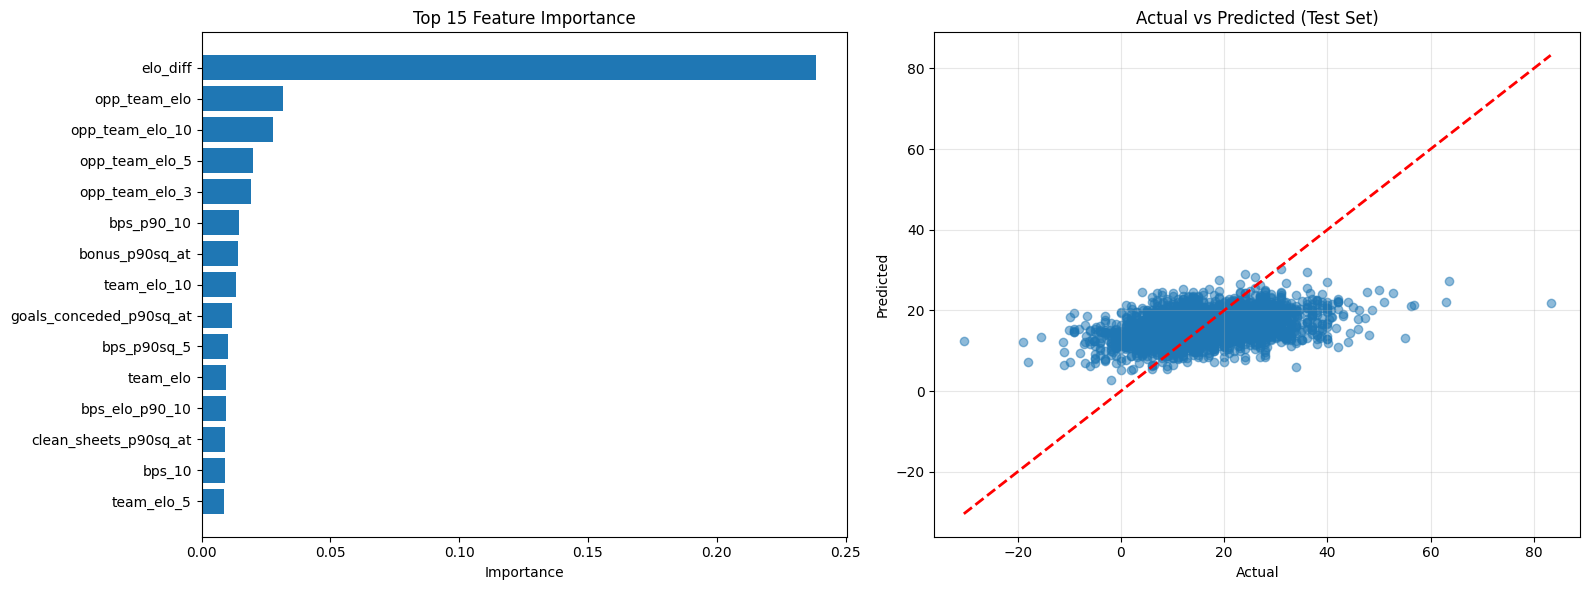

target=bps_per90, GK_bps_predictor
Cleaned df size: 3907/4149

Training Set Performance:
R² Score: 0.5237
RMSE: 6.1325
MAE: 4.9962

Test Set Performance:
R² Score: 0.0397
RMSE: 8.8748
MAE: 6.9630

Top 20 Feature Importances:
                feature  importance
           opp_team_elo    0.033359
        opp_team_elo_10    0.031708
           bps_p90sq_10    0.024647
  opp_team_elo_p90sq_at    0.023858
                 bps_10    0.023294
        bps_elo_p90sq_3    0.021140
           bps_p90sq_at    0.020436
               elo_diff    0.018157
             bps_p90_10    0.017986
            bps_p90sq_3    0.017334
goals_conceded_p90sq_at    0.016903
         saves_p90sq_10    0.016651
      saves_elo_p90sq_3    0.016601
       bps_elo_p90sq_10    0.016410
  opp_team_elo_p90sq_10    0.016224
            bps_p90sq_5    0.015981
   opp_team_elo_p90sq_3    0.015287
         opp_team_elo_3    0.015039
         saves_p90sq_at    0.014693
  total_points_p90sq_10    0.014391


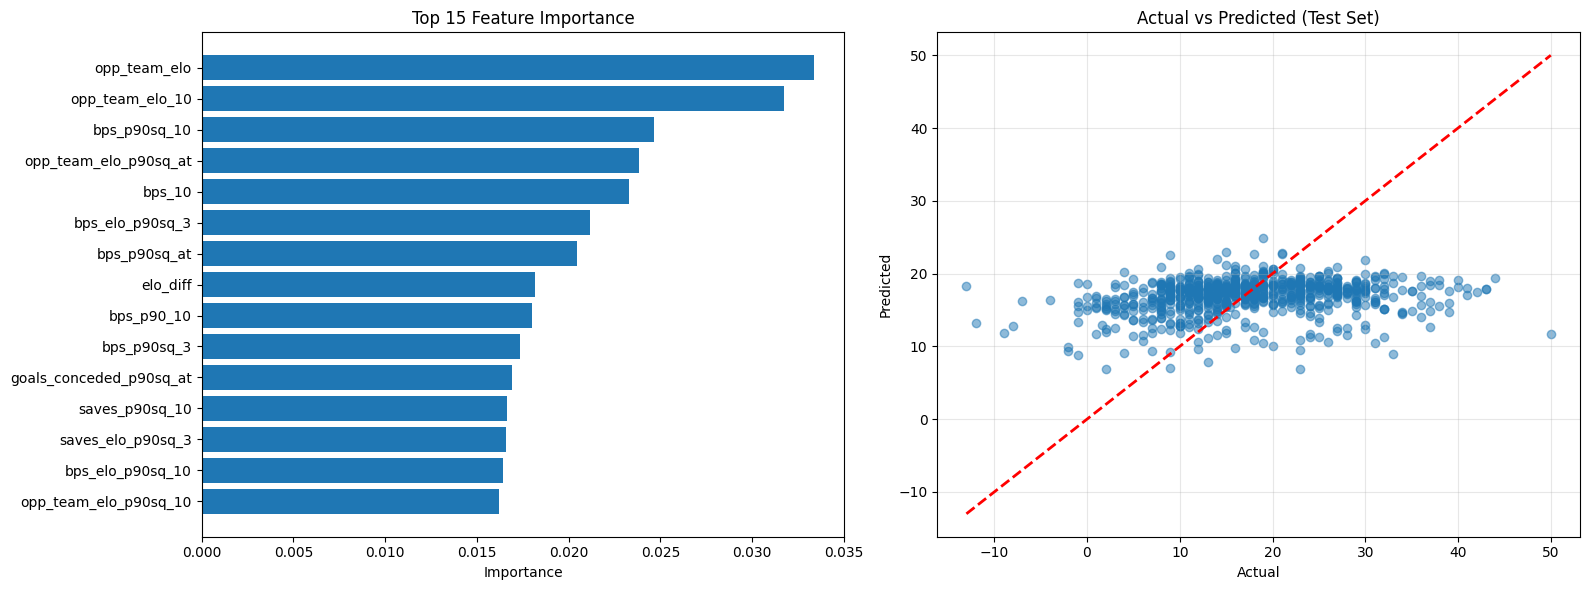

In [16]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=bps_per90, FWD_bps_predictor")
    FWD_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90', # try: 'bonus_per90'
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_bps_predictor.fit()
    FWD_bps_predictor.plot_results()

    print("target=bps_per90, MID_bps_predictor")
    MID_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_bps_predictor.fit()
    MID_bps_predictor.plot_results()
    
    print("target=bps_per90, DEF_bps_predictor")
    DEF_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_bps_predictor.fit()
    DEF_bps_predictor.plot_results()

    print("target=bps_per90, GK_bps_predictor")
    GK_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10)
    GK_bps_predictor.fit()
    GK_bps_predictor.plot_results()

target=saves_per90, GK_saves_predictor
Cleaned df size: 3907/4169

Training Set Performance:
R² Score: 0.6008
RMSE: 1.2559
MAE: 1.0145

Test Set Performance:
R² Score: 0.0405
RMSE: 1.7944
MAE: 1.4412

Top 20 Feature Importances:
                  feature  importance
                 elo_diff    0.134281
             opp_team_elo    0.023158
           saves_p90sq_at    0.019164
    opp_team_elo_p90sq_at    0.018311
  goals_conceded_p90sq_at    0.017051
           opp_team_elo_5    0.016859
          opp_team_elo_10    0.015312
        team_elo_p90sq_at    0.014850
       saves_elo_p90sq_10    0.014351
          bps_elo_p90sq_5    0.014317
             bps_p90sq_at    0.013907
           saves_p90sq_10    0.013512
    total_points_p90sq_at    0.012757
             bps_p90sq_10    0.011883
 total_points_elo_p90sq_5    0.011745
           opp_team_elo_3    0.011688
    opp_team_elo_p90sq_10    0.011625
            saves_p90sq_3    0.011183
total_points_elo_p90sq_10    0.011028
     opp_te

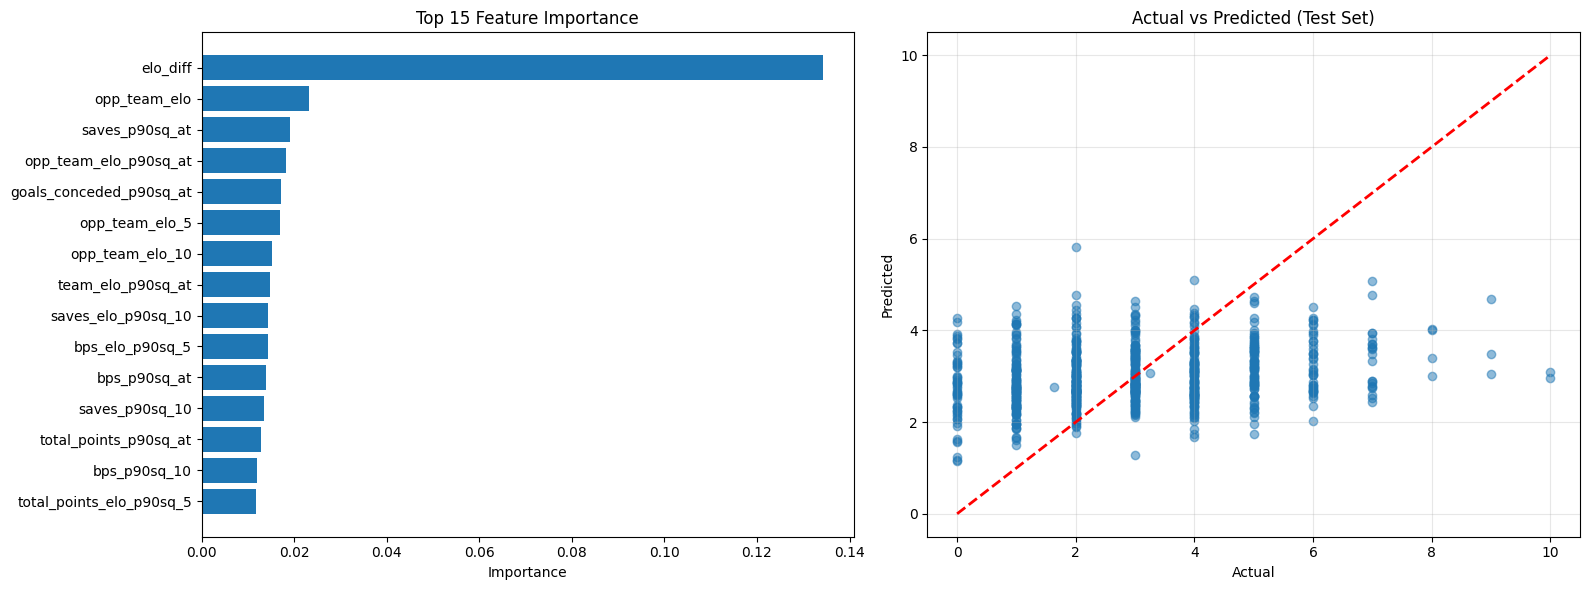

In [17]:
#shots saved
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=saves_per90, GK_saves_predictor")
    GK_saves_predictor = FPLPredictor(
        data=df[filtered],
        target='saves_per90',
        positions={'GK'},
        max_nan_pct=10)
    GK_saves_predictor.fit()
    GK_saves_predictor.plot_results()

target=defensive_contribution_per90, FWD_defcon_predictor
Cleaned df size: 641/5128

Training Set Performance:
R² Score: 0.7947
RMSE: 1.2875
MAE: 1.0331

Test Set Performance:
R² Score: 0.0266
RMSE: 2.7907
MAE: 2.1915

Top 20 Feature Importances:
                feature  importance
  clean_sheets_p90sq_at    0.041584
   total_points_p90sq_3    0.032890
goals_conceded_p90sq_at    0.025930
           bps_p90sq_at    0.024477
         opp_team_elo_5    0.019243
        opp_team_elo_10    0.019038
           opp_team_elo    0.018033
  opp_team_elo_p90sq_at    0.015588
  opp_team_elo_p90sq_10    0.015305
      team_elo_p90sq_10    0.015106
         opp_team_elo_3    0.014716
     minutes_elo_p90_10    0.014270
        xg_over_g_ratio    0.013366
             minutes_10    0.012981
  goals_scored_p90sq_at    0.012774
   opp_team_elo_p90sq_5    0.012710
   opp_team_elo_p90sq_3    0.012577
   goals_conceded_elo_3    0.012576
  goals_conceded_p90_10    0.012516
            bps_p90sq_5    0.0124

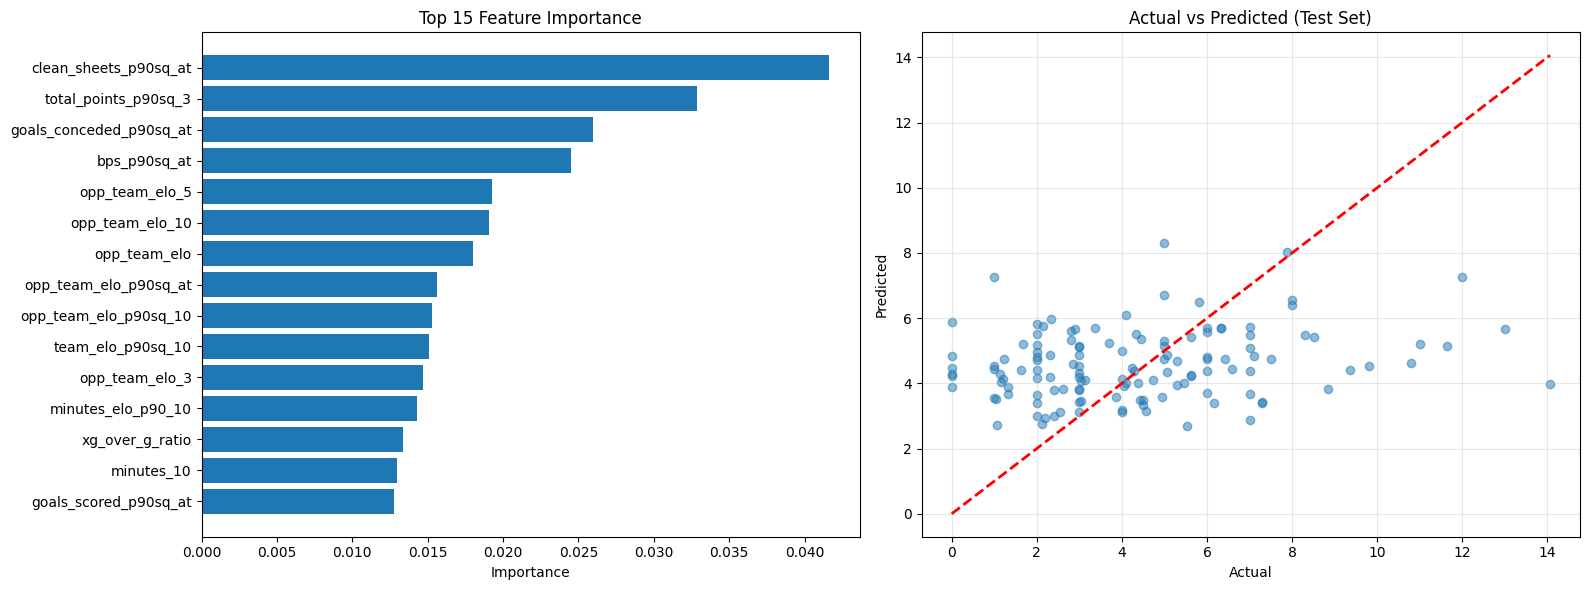

target=defensive_contribution_per90, MID_defcon_predictor
Cleaned df size: 2903/21162

Training Set Performance:
R² Score: 0.6796
RMSE: 2.3780
MAE: 1.9245

Test Set Performance:
R² Score: 0.1829
RMSE: 3.8543
MAE: 2.9909

Top 20 Feature Importances:
                    feature  importance
      goals_scored_p90sq_at    0.098695
    goals_conceded_p90sq_at    0.034615
             bonus_p90sq_at    0.026439
      total_points_p90sq_at    0.024073
               bps_p90sq_at    0.020105
                   team_elo    0.016364
      goals_conceded_elo_10    0.015974
          team_elo_p90sq_at    0.014724
               opp_team_elo    0.014703
                   elo_diff    0.013158
      clean_sheets_p90sq_at    0.013153
           team_elo_p90sq_5    0.012401
goals_conceded_elo_p90sq_10    0.012061
             opp_team_elo_3    0.011807
        team_elo_elo_p90_10    0.011378
      opp_team_elo_p90sq_at    0.011374
       opp_team_elo_p90sq_3    0.010989
         minutes_elo_p90_10    

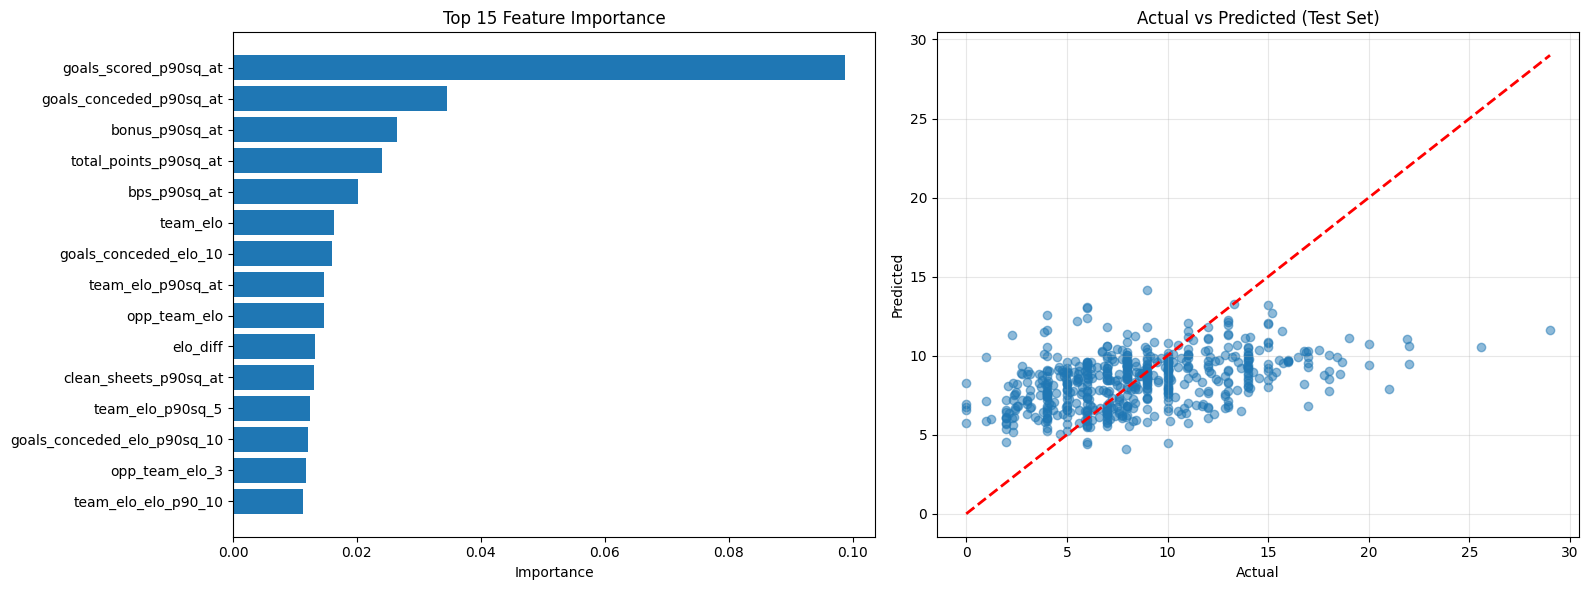

target=defensive_contribution_per90, DEF_defcon_predictor
Cleaned df size: 2426/17936

Training Set Performance:
R² Score: 0.6569
RMSE: 2.2876
MAE: 1.8570

Test Set Performance:
R² Score: 0.0700
RMSE: 3.6763
MAE: 2.8866

Top 20 Feature Importances:
                                   feature  importance
                                cbi_p90_at    0.067697
xgoal_involvements_x_defensive_cont_p90_at    0.028298
                   opp_team_elo_elo_p90_10    0.021107
                   goals_conceded_p90sq_at    0.020637
                     opp_team_elo_p90sq_at    0.020361
                              opp_team_elo    0.019466
                                  elo_diff    0.018601
                            tackles_p90_at    0.018424
                         recoveries_p90_at    0.014492
                            bonus_p90sq_at    0.014361
                       team_elo_elo_p90_10    0.014263
                     total_points_p90sq_at    0.013853
                            opp_team

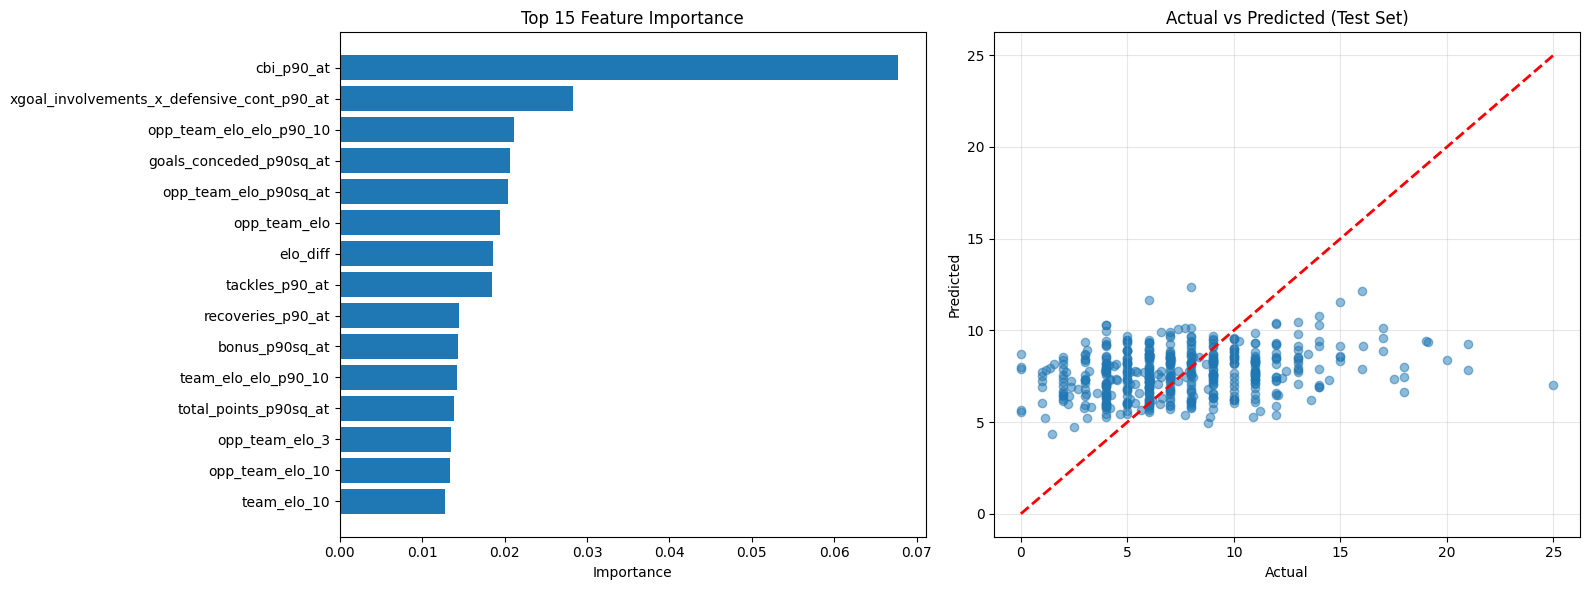

In [18]:
# >10 defcon (CBIT) for a defender
# >12 defcon (CBIT+R) for mid or fwd
filtered = (df['minutes']>30)&(df['player_season_minutes_total']>0)

if __name__ == "__main__":
    
    print("target=defensive_contribution_per90, FWD_defcon_predictor")
    FWD_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'FWD'},
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_defcon_predictor.fit()
    FWD_defcon_predictor.plot_results()

    print("target=defensive_contribution_per90, MID_defcon_predictor")
    MID_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'MID'},
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_defcon_predictor.fit()
    MID_defcon_predictor.plot_results()

    print("target=defensive_contribution_per90, DEF_defcon_predictor")
    DEF_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'DEF'},
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_defcon_predictor.fit()
    DEF_defcon_predictor.plot_results()

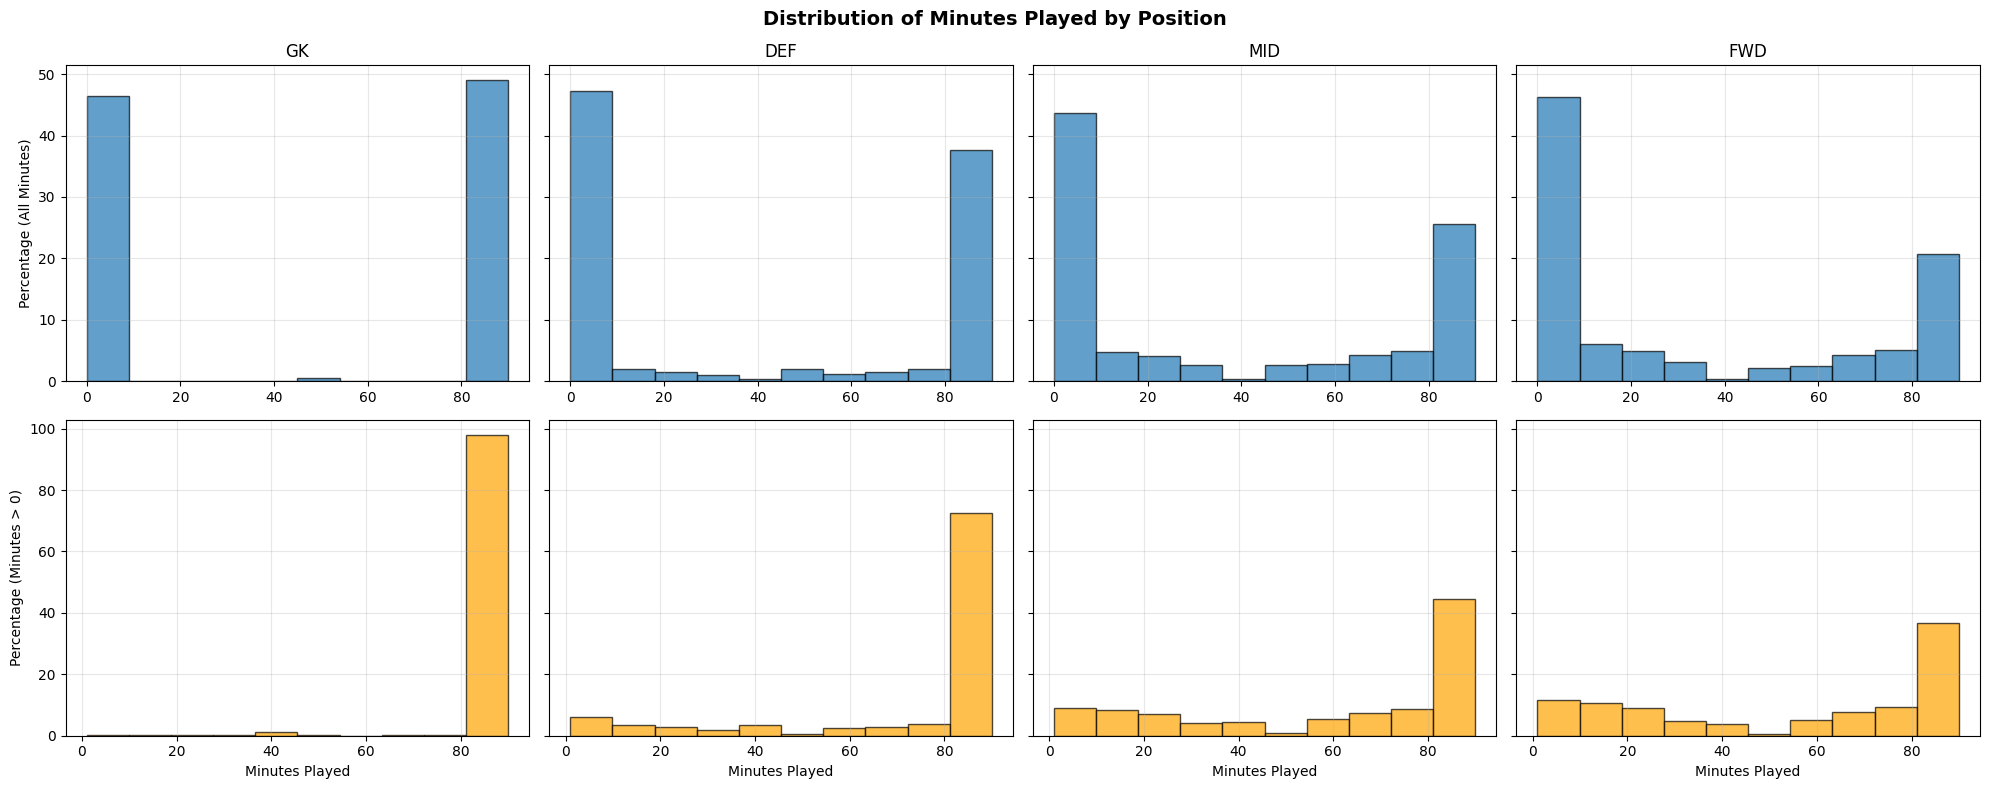

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Filter for specific positions
positions = ['GK', 'DEF', 'MID', 'FWD']
n_positions = len(positions)

# Create subplots with 2 rows
fig, axes = plt.subplots(2, n_positions, figsize=(5*n_positions, 8), sharey='row')

# Row 1: All data
for i, position in enumerate(positions):
    position_minutes = df[df['position'] == position]['minutes']
    axes[0, i].hist(position_minutes, bins=10, edgecolor='black', alpha=0.7, 
                    weights=100*np.ones(len(position_minutes))/len(position_minutes))
    axes[0, i].set_title(position)
    axes[0, i].grid(True, alpha=0.3)

axes[0, 0].set_ylabel('Percentage (All Minutes)')

# Row 2: Minutes > 0
for i, position in enumerate(positions):
    position_minutes = df[(df['position'] == position) & (df['minutes'] > 0)]['minutes']
    axes[1, i].hist(position_minutes, bins=10, edgecolor='black', alpha=0.7, color='orange',
                    weights=100*np.ones(len(position_minutes))/len(position_minutes))
    axes[1, i].set_xlabel('Minutes Played')
    axes[1, i].grid(True, alpha=0.3)

axes[1, 0].set_ylabel('Percentage (Minutes > 0)')

plt.suptitle('Distribution of Minutes Played by Position', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Goals conceded per 90
Estimated λ (mean goals per match): 1.358


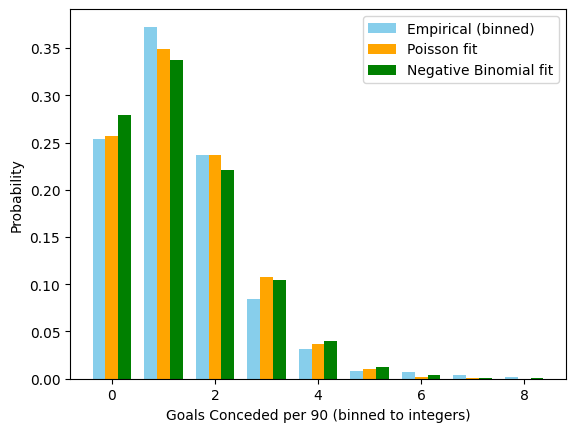

Mean: 1.348, Variance: 1.506
Overdispersion ratio (Var/Mean): 1.117
✅ Poisson assumption looks reasonable.
P(X < 1 goal) = 0.257


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("Goals conceded per 90")

# Compute xGC per 90
data = df.copy()
data['xgc_p90'] = (data['expected_goals_conceded'] / data['minutes']) * 90

# Filter to reasonable samples
data = data[(data['minutes'] > 0) & (data['xgc_p90'] < 8)]['xgc_p90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean goals per match): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('Goals Conceded per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")

# --- Example probability ---
p_less_than_1 = poisson.cdf(0, mu=lambda_hat)
print(f"P(X < 1 goal) = {p_less_than_1:.3f}")


Mids & Forwards
Estimated λ (mean defcon per 90): 8.210


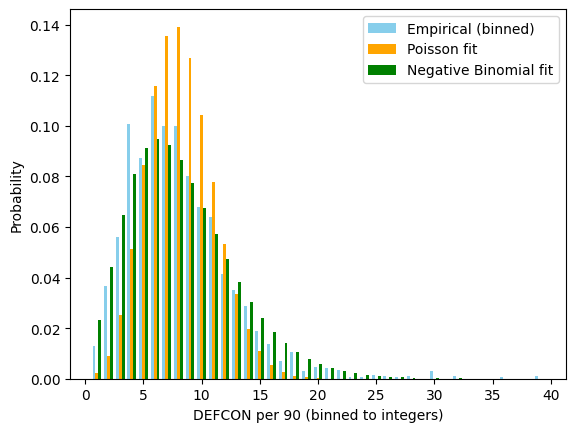

Mean: 8.203, Variance: 21.268
Overdispersion ratio (Var/Mean): 2.593
⚠️ Likely overdispersed → Negative Binomial may fit better.


In [21]:
#Test if defcon_p90 is neg binom distributed

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("Mids & Forwards")

# Filter to reasonable samples
data = df[(df['minutes'] > 0)
          & (df['defensive_contribution_per90'] > 0) 
          & (df['defensive_contribution_per90'] < 40)
          & (df['position'].isin(['DEF']))]['defensive_contribution_per90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean defcon per 90): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('DEFCON per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")


GK saves per 90
Estimated λ (mean saves per 90): 3.199


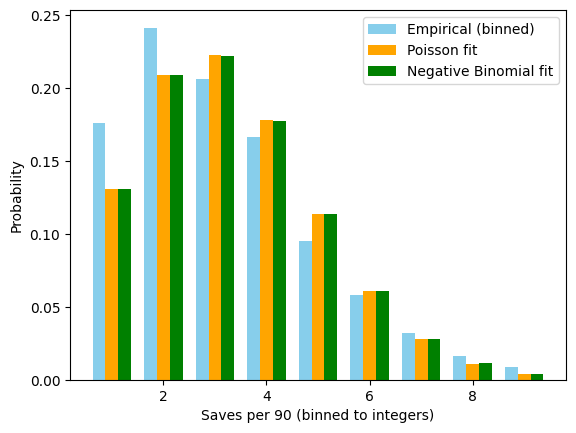

Mean: 3.199, Variance: 3.215
Overdispersion ratio (Var/Mean): 1.005
✅ Poisson assumption looks reasonable.


In [22]:
#Test if saves_p90 is neg binom distributed

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("GK saves per 90")

# Filter to reasonable samples
data = df[#(df['minutes'] > 0)
          (df['saves_per90'] > 0) 
          & (df['saves_per90'] < 10)
          & (df['position'].isin(['GK']))]['saves_per90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean saves per 90): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('Saves per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")


In [23]:
#Create the data which the prediction data should be added to
prediction_data = df[(df['season']==20252026)
                     &(df['event']>=current_gw+1)]

In [24]:
def predict_target_vectorized(df, model_dict, col_name):
    preds = []
    
    for pos, model in model_dict.items():
        subset = df[df['position'] == pos]
        if not subset.empty:
            pos_preds = model.predict_new(subset)
            temp = subset.copy()
            temp[col_name] = pos_preds
            preds.append(temp)
    
    if not preds:
        # If no positions matched at all
        return pd.Series(index=df.index, dtype=float)
    
    result = pd.concat(preds)
    
    # Safely align back to original DataFrame
    output = pd.Series(index=df.index, dtype=float)
    output.loc[result.index] = result[col_name]
    return output

In [25]:
target_col_name = 'mins_pred'
mins_model_dict = {'FWD': FWD_mins_predictor, 'MID': MID_mins_predictor, 'DEF': DEF_mins_predictor, 'GK': GK_mins_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, mins_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_752\2521843321.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, mins_model_dict, col_name=target_col_name)


count    4033.000000
mean       59.431098
std        19.830726
min        16.113031
25%        41.393084
50%        59.310895
75%        78.171096
max        89.971779
Name: mins_pred, dtype: float64

In [26]:
target_col_name = 'xgp90_pred'
xg_model_dict = {'FWD': FWD_xG_predictor, 'MID': MID_xG_predictor, 'DEF': DEF_xG_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xg_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_752\365369552.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xg_model_dict, col_name=target_col_name)


count    3767.000000
mean        0.163811
std         0.141842
min         0.025481
25%         0.062820
50%         0.120392
75%         0.202520
max         0.810315
Name: xgp90_pred, dtype: float64

In [27]:
target_col_name = 'xap90_pred'
xA_model_dict = {'FWD': FWD_xA_predictor, 'MID': MID_xA_predictor, 'DEF': DEF_xA_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xA_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_752\4144355699.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xA_model_dict, col_name=target_col_name)


count    3767.000000
mean        0.103419
std         0.068115
min         0.029233
25%         0.050870
50%         0.077840
75%         0.138252
max         0.357596
Name: xap90_pred, dtype: float64

In [28]:
target_col_name = 'xgcp90_pred'
xGC_model_dict = {'FWD': FWD_xGC_predictor, 'MID': MID_xGC_predictor, 'DEF': DEF_xGC_predictor, 'GK':GK_xGC_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xGC_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_752\682035545.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xGC_model_dict, col_name=target_col_name)


count    4033.000000
mean        1.404855
std         0.315168
min         0.384201
25%         1.190025
50%         1.382035
75%         1.601497
max         2.778382
Name: xgcp90_pred, dtype: float64

In [29]:
target_col_name = 'xbpsp90_pred'
bps_model_dict = {'FWD': FWD_bps_predictor, 'MID': MID_bps_predictor, 'DEF': DEF_bps_predictor, 'GK':GK_bps_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, bps_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_752\3051138591.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, bps_model_dict, col_name=target_col_name)


count    4033.000000
mean       16.001695
std         3.232207
min         6.397027
25%        13.772889
50%        15.570662
75%        17.837458
max        42.540832
Name: xbpsp90_pred, dtype: float64

                                 OLS Regression Results                                
Dep. Variable:                  bonus   R-squared (uncentered):                   0.448
Model:                            OLS   Adj. R-squared (uncentered):              0.448
Method:                 Least Squares   F-statistic:                          3.504e+04
Date:                Sun, 15 Mar 2026   Prob (F-statistic):                        0.00
Time:                        09:50:07   Log-Likelihood:                         -40633.
No. Observations:               43142   AIC:                                  8.127e+04
Df Residuals:                   43141   BIC:                                  8.128e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

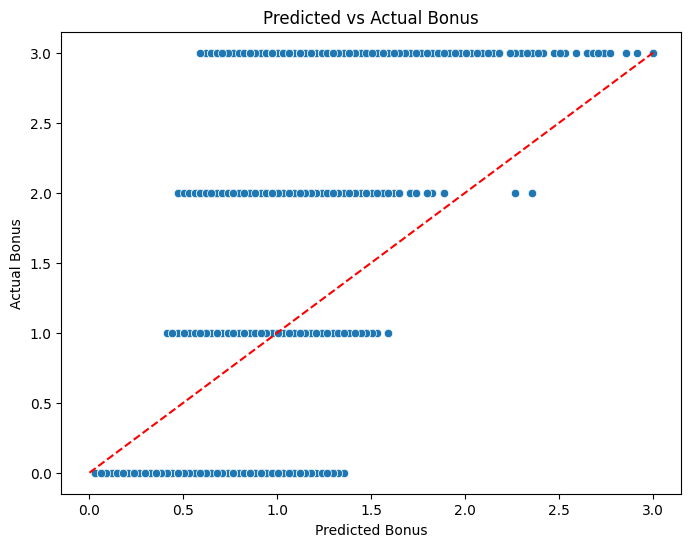

Actual Bonus       0.0       1.0       2.0       3.0
Position                                            
DEF           0.458751  0.228549  1.105768  1.946814
FWD           0.332346  0.196816  1.046059  1.707026
GK            0.488017  0.244117  1.113804  2.006169
GKP                NaN       NaN       NaN       NaN
MID           0.397312  0.244604  1.047837  1.823077


C:\Users\Chris\AppData\Local\Temp\ipykernel_752\3541705010.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_table = dfb.groupby(['position', 'bonus']).apply(lambda x: rmse(x['bonus'], x['bonus_pred']))


In [30]:
# Generalize the relationship between bps & bonus points
import statsmodels.formula.api as smf
dfb=df.copy()
filtered = (dfb['minutes']>45) & (dfb['bonus']>=0) & (dfb['bps']>0) & (dfb['position'].isin(['GK','DEF','MID','FWD']))
# df['bonus_sq'] = df['bonus']**2

model = smf.ols('bonus ~ bps -1', data=dfb[filtered]).fit()
print(model.summary())

dfb['bonus_pred'] = model.predict(dfb[filtered])
dfb['bonus_pred'] = np.clip(dfb['bonus_pred'], 0, 3) # clip prediction to 3

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x='bonus_pred', y='bonus', data=dfb)
plt.plot([dfb['bonus'].min(), dfb['bonus'].max()],
         [dfb['bonus'].min(), dfb['bonus'].max()],
         color='red', linestyle='--')  # 45-degree line
plt.xlabel('Predicted Bonus')
plt.ylabel('Actual Bonus')
plt.title('Predicted vs Actual Bonus')
plt.show()

import pandas as pd
import numpy as np

# Function to calculate RMSE
def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

# Group by position and actual bonus, then calculate RMSE
rmse_table = dfb.groupby(['position', 'bonus']).apply(lambda x: rmse(x['bonus'], x['bonus_pred']))

# Convert to DataFrame
rmse_table = rmse_table.reset_index()
rmse_table.columns = ['Position', 'Actual Bonus', 'RMSE']

pivot_rmse = rmse_table.pivot(index='Position', columns='Actual Bonus', values='RMSE')
print(pivot_rmse)


In [31]:
#Add bonus prediction to data
prediction_data['bonus_pred'] = model.predict(prediction_data)
print("bonus_pred added to prediction data")

bonus_pred added to prediction data


C:\Users\Chris\AppData\Local\Temp\ipykernel_752\2545047019.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['bonus_pred'] = model.predict(prediction_data)


In [32]:
target_col_name = 'xsavesp90_pred'
saves_model_dict = {'GK':GK_saves_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, saves_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_752\803536942.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, saves_model_dict, col_name=target_col_name)


count    266.000000
mean       3.190156
std        0.632709
min        1.620472
25%        2.693953
50%        3.103925
75%        3.588297
max        5.075052
Name: xsavesp90_pred, dtype: float64

In [33]:
target_col_name = 'xdefconp90_pred'
defcon_model_dict = {'FWD': FWD_defcon_predictor, 'MID': MID_defcon_predictor, 'DEF': DEF_defcon_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, defcon_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_752\2777375241.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, defcon_model_dict, col_name=target_col_name)


count    3767.000000
mean        7.958051
std         1.841966
min         2.470005
25%         6.748206
50%         8.047772
75%         9.293568
max        15.373980
Name: xdefconp90_pred, dtype: float64

In [34]:
prediction_data[prediction_data['position']=='MID'].head()[["player_name_id","element","value","team_name","position","season","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xgcp90_pred'
    ]]

,player_name_id,element,value,team_name,position,season,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xgcp90_pred
130044,Adama Traoré Diarra,326.0,51.0,West Ham,MID,20252026.0,31.0,Aston Villa,1136.792544,33.835090,0.094968,0.074899,1.594511
130046,Adama Traoré Diarra,326.0,51.0,West Ham,MID,20252026.0,32.0,Wolves,942.107583,33.695295,0.094988,0.101841,1.158073
130054,Adama Traoré Diarra,326.0,51.0,West Ham,MID,20252026.0,33.0,Crystal Palace,1049.725045,33.474548,0.091723,0.083376,1.595905
130056,Adama Traoré Diarra,326.0,51.0,West Ham,MID,20252026.0,34.0,Everton,1063.420185,33.474548,0.091723,0.082686,1.608728
130058,Adama Traoré Diarra,326.0,51.0,West Ham,MID,20252026.0,35.0,Brentford,1079.913962,33.474548,0.091723,0.082262,1.622806


In [35]:
prediction_data[
    (prediction_data['event']==current_gw+1)
    &(prediction_data['mins_pred']>0)
    ][["player_name_id","element","value","team_name","position","season","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xgcp90_pred'
    ]].sort_values(by='xgp90_pred',ascending=False
        ).head(10)

,player_name_id,element,value,team_name,position,season,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xgcp90_pred
141753,Marc Guiu Paz,252.0,41.0,Chelsea,FWD,20252026.0,31.0,Everton,1063.420185,46.456018,0.810315,0.289140,1.555066
135666,Fábio Freitas Gouveia Carvalho,123.0,47.0,Brentford,MID,20252026.0,31.0,Leeds,979.720129,42.830633,0.739401,0.353913,1.601318
138899,Jonah Kusi-Asare,737.0,45.0,Fulham,FWD,20252026.0,31.0,Burnley,891.228204,30.995378,0.656699,0.253497,2.090982
130135,Alexander Isak,499.0,103.0,Liverpool,FWD,20252026.0,31.0,Brighton,1080.364275,35.140209,0.656400,0.316010,1.532398
147162,Stefanos Tzimas,180.0,52.0,Brighton,FWD,20252026.0,31.0,Liverpool,1169.189453,33.420456,0.630601,0.236708,1.633486
131207,Arnaud Kalimuendo,696.0,60.0,Nott'm Forest,FWD,20252026.0,31.0,Spurs,961.910656,27.825594,0.625819,0.283000,1.838354
143899,Niclas Füllkrug,625.0,56.0,West Ham,FWD,20252026.0,31.0,Aston Villa,1136.792544,32.112021,0.623846,0.277208,2.090593
145325,Reiss Nelson,27.0,48.0,Brentford,MID,20252026.0,31.0,Leeds,979.720129,35.528063,0.612943,0.301489,1.707574
132525,Callum Wilson,671.0,58.0,West Ham,FWD,20252026.0,31.0,Aston Villa,1136.792544,40.302661,0.595104,0.085134,1.800372
132209,Callum Marshall,626.0,43.0,West Ham,FWD,20252026.0,31.0,Aston Villa,1136.792544,41.681523,0.578055,0.262536,2.072511


In [36]:
import pandas as pd
from scipy.stats import nbinom

def calculate_negbinom_parameters(position_list, df):

    # 1. Calculate mean and variance
    filtered = (df['minutes'] > 0) & (df['defensive_contribution_per90'] > 0) & (df['defensive_contribution_per90'] < 40) & (df['position'].isin(position_list))
    mean = df[filtered]['defensive_contribution_per90'].mean()
    variance = df[filtered]['defensive_contribution_per90'].var()
    # r = number of successes
    r = (mean**2) / (variance - mean)
    # p = success probability
    p = r / (r + mean)
    return r,p

In [37]:
from scipy.stats import poisson
import numpy as np

def expected_score(mu, max_events=10, rule=None, points_per_n=None, points_value=None):
    """
    Calculate the expected score given an average event rate (mu)
    using a Poisson model.

    Parameters
    ----------
    mu : float
        Expected number of events (e.g., goals conceded, shots saved).
    max_events : int
        Maximum number of discrete events to sum over.
    rule : callable, optional
        Function that maps event count -> points. Example: lambda k: -np.floor(k / 2)
    points_per_n : int, optional
        For simple rules: number of events required for one point (e.g. 3 shots saved = 1 pt)
    points_value : float, optional
        Value of that one point (e.g. +1 for shots saved, -1 for goals conceded)

    Returns
    -------
    float
        Expected points based on Poisson-distributed event counts.
    """
    array = np.arange(0, max_events + 1)
    probs = poisson.pmf(array, mu)

    if rule is not None:
        scores = np.array([rule(k) for k in array])
    elif points_per_n is not None and points_value is not None:
        # General simple rule: 1 point_value for every n events
        scores = np.floor(array / points_per_n) * points_value
    else:
        raise ValueError("You must provide either a rule function or both points_per_n and points_value.")

    return np.sum(scores * probs)


In [38]:
from scipy.stats import norm
import numpy as np

scoring_dict = {
    "FWD": {'xgp90_pred': 4, 'xap90_pred': 3, 'xgcp90_pred': 0, 'xgc_ss':0, 'defcon':2},
    "MID": {'xgp90_pred': 5, 'xap90_pred': 3, 'xgcp90_pred': 1, 'xgc_ss':0, 'defcon':2},
    "DEF": {'xgp90_pred': 6, 'xap90_pred': 3, 'xgcp90_pred': 4, 'xgc_ss':-1, 'defcon':2},
    "GK":  {'xgp90_pred': 10, 'xap90_pred': 3, 'xgcp90_pred': 4, 'xgc_ss':-1, 'defcon':2}
}

def scoring(x, scoring_dict, points_type, negbinom_rp_dict=None):
    mins_factor = x['mins_pred']/90
    if points_type == 'mins':
        if pd.isna(x['mins_pred']):
            return 0
        elif x['mins_pred'] > 0:
            return 1 + 1 / (1 + np.exp(-(x['mins_pred'] - 60) / 10)) #smooth logistic approximation from 1 to 2 points, 10 is a scale factor
        
    if points_type == 'goals':
        goals_points = mins_factor * x['xgp90_pred'] * scoring_dict[x['position']]['xgp90_pred']
        return goals_points
    if points_type == 'assists':
        assist_points = mins_factor * x['xap90_pred'] * scoring_dict[x['position']]['xap90_pred']
        return assist_points
    if points_type == 'clean_sheets':
        p_less_than_1 = poisson.cdf(0, mu=x['xgcp90_pred'])
        cs_points = p_less_than_1 * scoring_dict[x['position']]['xgcp90_pred']
        return cs_points
    
    if points_type == 'shots_saved': 
        if x['position'] == 'GK':
            saves_points = expected_score(mu=x['xsavesp90_pred'],  # expected shots saved per 90
                                   max_events=15,
                                   points_per_n=3, #for every 3 shots saved
                                   points_value=1) #scores 1 point
            return saves_points
        else:
            return 0
        
    if points_type == 'goals_conceded':
        if x['position'] in ['DEF','GK']:
            gc_points = expected_score(mu=x['xgcp90_pred'], 
                                   max_events=10, 
                                   points_per_n=2, #for every 2 goals conceded 
                                   points_value=-1) #scores -1 points 
            return gc_points
        else:
            return 0

    if points_type == 'defcon':
        pos = x['position']
        if pos in ['MID','FWD']:
            r = negbinom_rp_dict[pos]['r']
            p = negbinom_rp_dict[pos]['p']
            k = 12
            prob_more_than_12 = 1 - nbinom.cdf(k, r, p)
            defcon_points = prob_more_than_12 * scoring_dict[pos]['defcon']
            return defcon_points
        elif pos == 'DEF':
            r = negbinom_rp_dict[pos]['r']
            p = negbinom_rp_dict[pos]['p']
            k = 10
            prob_more_than_12 = 1 - nbinom.cdf(k, r, p)
            defcon_points = prob_more_than_12 * scoring_dict[pos]['defcon']
            return defcon_points
        else: return 0

    if points_type == 'bonus':
        return x['xbpsp90_pred']*0.0294 # ols regression coefficient

prediction_data['xpoints_mins'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='mins'), axis=1)
prediction_data['xpoints_goals'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals'), axis=1)
prediction_data['xpoints_assists'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='assists'), axis=1)
prediction_data['xpoints_clean_sheets'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='clean_sheets'), axis=1)

prediction_data['xpoints_shots_saved'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='shots_saved'), axis=1)
prediction_data['xpoints_goals_conceded'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals_conceded'), axis=1)

def_r,def_p = calculate_negbinom_parameters(['DEF'], df)
mid_r,mid_p = calculate_negbinom_parameters(['MID'], df)
fwd_r,fwd_p = calculate_negbinom_parameters(['FWD'], df)
rp_dict = {'DEF':{'r':def_r,'p':def_p},'MID':{'r':mid_r,'p':mid_p},'FWD':{'r':fwd_r,'p':fwd_p}}
prediction_data['xpoints_defcon'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='defcon', negbinom_rp_dict=rp_dict), axis=1)
prediction_data['xpoints_bonus'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='bonus'), axis=1)

prediction_data['xpoints'] = prediction_data[['xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets',
                                              'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus']].sum(axis=1, skipna=True)

C:\Users\Chris\AppData\Local\Temp\ipykernel_752\3158721815.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['xpoints_mins'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='mins'), axis=1)
C:\Users\Chris\AppData\Local\Temp\ipykernel_752\3158721815.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['xpoints_goals'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals'), axis=1)
C:\Users\Chris\AppData\Local\Temp\ipykernel_75

In [39]:
predictions = prediction_data[['player_name_id', 'team_name','team_elo','element','position','opp_team_name','opp_team_elo', 'season', 'value', 'event',
                       'mins_pred', 'xgp90_pred', 'xap90_pred', 'xgcp90_pred',
                       'xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets','xpoints_shots_saved',
                       'xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                       'xpoints']]

In [40]:
table_name = "predictions"
if __name__ == "__main__":
    db_creator.create_staging_table_then_insert_data(table_name, data=predictions)
    preds = db_creator.table_to_df(table_name=table_name)
    print(preds.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4033 entries, 0 to 4032
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   player_name_id          4033 non-null   object 
 1   team_name               4033 non-null   object 
 2   team_elo                4033 non-null   float64
 3   element                 4033 non-null   float64
 4   position                4033 non-null   object 
 5   opp_team_name           4033 non-null   object 
 6   opp_team_elo            4033 non-null   float64
 7   season                  4033 non-null   float64
 8   value                   4033 non-null   float64
 9   event                   4033 non-null   float64
 10  mins_pred               4033 non-null   float64
 11  xgp90_pred              3767 non-null   float64
 12  xap90_pred              3767 non-null   float64
 13  xgcp90_pred             4033 non-null   float64
 14  xpoints_mins            4033 non-null   

In [41]:
# Add new columns to the xPoints table
db_creator.execute_sql("""
    ALTER TABLE predictions
    ADD COLUMN IF NOT EXISTS in_any_team INTEGER DEFAULT 0,
    ADD COLUMN IF NOT EXISTS in_my_team INTEGER DEFAULT 0
""")

In [42]:
my_name = "Christopher Harris"

# Get the player lists
view = db_creator.run_sql(f"""
    WITH 
    current_players AS (
        SELECT element
        FROM fpl_picks
        WHERE gw = {current_gw}
    ),
    my_players AS (
        SELECT element
        FROM fpl_picks
        WHERE gw = {current_gw}
        AND member = '{my_name}'
    )
    SELECT * FROM my_players
""")

# Update the flags
db_creator.execute_sql(f"""
    UPDATE predictions
    SET in_any_team = 1
    WHERE element IN (
        SELECT element 
        FROM fpl_picks 
        WHERE gw = {current_gw}
    )
""")

db_creator.execute_sql(f"""
    UPDATE predictions
    SET in_my_team = 1
    WHERE element IN (
        SELECT element 
        FROM fpl_picks 
        WHERE gw = {current_gw}
        AND member = '{my_name}'
    )
""")

In [43]:
print(f"Gameweek {current_gw+1} Predictions")
prediction_data[
    prediction_data['event']==current_gw+1
][["player_name_id","element",'event',"value","team_name","position","opp_team_name","opp_team_elo"
   ,'mins_pred', 'xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets', 
   'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
   'xpoints'
   ]].sort_values(by='xpoints',ascending=False
    ).head(10)

Gameweek 31 Predictions


,player_name_id,element,event,value,team_name,position,opp_team_name,opp_team_elo,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
130278,Alex Iwobi,324.0,31.0,64.0,Fulham,MID,Burnley,891.228204,84.920660,1.923584,1.053803,0.640255,0.381209,0.0,0.000000,0.509208,0.624856,5.132915
143578,Morgan Gibbs-White,515.0,31.0,73.0,Nott'm Forest,MID,Spurs,961.910656,85.179102,1.925388,1.077073,0.418815,0.363809,0.0,0.000000,0.509208,0.560845,4.855139
132232,Bruno Borges Fernandes,449.0,31.0,101.0,Man Utd,MID,Bournemouth,1066.816076,76.685978,1.841389,0.929942,0.717814,0.239643,0.0,0.000000,0.509208,0.570701,4.808697
135666,Fábio Freitas Gouveia Carvalho,123.0,31.0,47.0,Brentford,MID,Leeds,979.720129,42.830633,1.152266,1.759390,0.505277,0.201631,0.0,0.000000,0.509208,0.674710,4.802482
135158,Ezri Konsa Ngoyo,38.0,31.0,44.0,Aston Villa,DEF,West Ham,993.767441,86.782546,1.935731,0.265516,0.128892,1.573509,0.0,-0.255180,0.539633,0.579016,4.767117
132998,Cole Palmer,235.0,31.0,106.0,Chelsea,MID,Everton,1063.420185,81.099378,1.891865,0.947375,0.564566,0.225924,0.0,0.000000,0.509208,0.504015,4.642954
142714,Matty Cash,36.0,31.0,48.0,Aston Villa,DEF,West Ham,993.767441,76.451219,1.838231,0.244136,0.137365,1.567775,0.0,-0.256724,0.539633,0.567920,4.638335
133200,Crysencio Summerville,615.0,31.0,57.0,West Ham,MID,Aston Villa,1136.792544,83.600480,1.913730,1.008186,0.377088,0.248249,0.0,0.000000,0.509208,0.557045,4.613507
132519,Calvin Bassey,318.0,31.0,44.0,Fulham,DEF,Burnley,891.228204,78.353940,1.862403,0.257821,0.136234,1.524822,0.0,-0.268538,0.539633,0.558965,4.611340
143421,Mohamed Salah,381.0,31.0,140.0,Liverpool,MID,Brighton,1080.364275,75.791076,1.829078,1.058567,0.396718,0.287416,0.0,0.000000,0.509208,0.524050,4.605037


In [44]:
print(f"Next 5 GWs: GW{current_gw+1} - GW{current_gw+5}")
next_5_gws_filter = (prediction_data['event']>=current_gw)&(prediction_data['event']<=current_gw+5)
prediction_data[next_5_gws_filter].groupby('player_name_id')[['mins_pred', 'xpoints_mins', 'xpoints_goals', 
                                           'xpoints_assists', 'xpoints_clean_sheets', 'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                                           'xpoints'
                                           ]].agg('sum').reset_index().sort_values(by='xpoints',ascending=False).head(10)

Next 5 GWs: GW31 - GW35


,player_name_id,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
362,Morgan Gibbs-White,425.770790,9.626074,5.498125,1.984787,1.548725,0.0,0.000000,2.546042,2.729551,23.933304
156,Fábio Freitas Gouveia Carvalho,215.192282,5.774908,8.823196,2.253592,0.933976,0.0,0.000000,2.546042,3.546658,23.878372
90,Crysencio Summerville,418.002398,9.568648,4.940383,2.311303,1.403930,0.0,0.000000,2.546042,2.824180,23.594486
64,Bruno Borges Fernandes,383.429892,9.206944,4.609393,3.061185,1.287144,0.0,0.000000,2.546042,2.881175,23.591883
143,Ezri Konsa Ngoyo,433.912728,9.678656,1.322977,0.650114,7.476933,0.0,-1.398026,2.698163,2.827775,23.256593
85,Cole Palmer,405.541107,9.459752,4.890326,2.562778,1.199253,0.0,0.000000,2.546042,2.531908,23.190059
118,Dominik Szoboszlai,417.686437,9.566151,4.169804,2.677499,1.334919,0.0,0.000000,2.546042,2.703530,22.997945
359,Mohamed Salah,378.955379,9.145390,5.244715,2.005766,1.456145,0.0,0.000000,2.546042,2.570818,22.968877
340,Matty Cash,382.977569,9.200829,1.220116,0.659727,7.310585,0.0,-1.461379,2.698163,2.798141,22.426182
267,Justin Kluivert,263.657440,6.629467,7.702322,1.908834,0.833770,0.0,0.000000,2.546042,2.599321,22.219757


In [45]:
print("Rest of Season Predictions")
prediction_data.groupby('player_name_id')[['mins_pred', 'xpoints_mins', 'xpoints_goals', 
                                           'xpoints_assists', 'xpoints_clean_sheets', 
                                           'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                                           'xpoints'
                                           ]].agg('sum').reset_index().sort_values(by='xpoints',ascending=False).head(10)

Rest of Season Predictions


,player_name_id,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
64,Bruno Borges Fernandes,613.487827,14.731110,7.408488,5.163485,2.159043,0.0,0.000000,4.073668,4.803666,38.339460
362,Morgan Gibbs-White,681.308095,15.402237,8.907175,3.034155,2.301666,0.0,0.000000,4.073668,4.321470,38.040371
90,Crysencio Summerville,668.134610,15.304413,7.894093,3.606085,2.182759,0.0,0.000000,4.073668,4.506992,37.568011
156,Fábio Freitas Gouveia Carvalho,345.104413,9.250349,14.168976,3.348151,1.435430,0.0,0.000000,4.073668,5.259597,37.536171
85,Cole Palmer,648.135043,15.128367,7.869198,4.123908,2.030604,0.0,0.000000,4.073668,4.111378,37.337122
265,Jurriën Timber,579.265651,13.347564,3.597968,1.660665,12.204197,0.0,-1.560587,3.777428,3.823862,36.851097
359,Mohamed Salah,606.328606,14.632625,8.404837,3.089456,2.265616,0.0,0.000000,4.073668,4.091049,36.557251
118,Dominik Szoboszlai,668.273947,15.305648,6.617556,3.986742,2.061036,0.0,0.000000,4.073668,4.330201,36.374851
267,Justin Kluivert,421.684654,10.603459,12.385339,3.128994,1.409156,0.0,0.000000,4.073668,4.084627,35.685241
143,Ezri Konsa Ngoyo,694.260365,15.485850,2.154497,1.025696,11.022522,0.0,-2.638020,4.317061,4.294345,35.661950


In [46]:
from datetime import datetime

# Add the columns
db_creator.execute_sql("""
    ALTER TABLE predictions
    ADD COLUMN IF NOT EXISTS prediction_timestamp TIMESTAMP,
    ADD COLUMN IF NOT EXISTS prediction_gameweek INTEGER;
""")

# Update ALL existing rows with current timestamp and gameweek
db_creator.execute_sql("""
    UPDATE predictions
    SET prediction_timestamp = :timestamp,
        prediction_gameweek = :gameweek;
""", params={
    'timestamp': datetime.now(),
    'gameweek': current_gw
})

In [47]:
# ## Reset predictions table

# db_creator.execute_sql("""
#     DROP TABLE IF EXISTS predictions_allgws
# """)

In [48]:
# Create predictions_allgws if it doesn't exist
db_creator.execute_sql("""
    CREATE TABLE IF NOT EXISTS predictions_allgws AS
    SELECT p.*,
            -- pg.player_name_id, pg.team_name, pg.team_elo, pg.element, pg.position, pg.opp_team_name, pg.opp_team_elo, pg.value -- these are in both tables
            pg.fixture, pg.total_points
            
    FROM predictions p
    LEFT JOIN playergw pg 
        ON p.player_name_id = pg.player_name_id 
        AND p.event = pg.event
        AND p.season = pg.season
    WHERE 1=0;  -- Empty table with correct schema
""")

In [49]:
# Step 1: Insert new predictions with current timestamp
# This will create NEW rows even for gameweeks that already have predictions
db_creator.execute_sql("""
INSERT INTO predictions_allgws (
    player_name_id, team_name, team_elo, element, position, opp_team_name, opp_team_elo, value, 
    event, season, xpoints, 
    prediction_timestamp, prediction_gameweek,
    fixture, total_points
)
SELECT 
    p.player_name_id, p.team_name, p.team_elo, p.element, p.position, p.opp_team_name, 
    p.opp_team_elo, p.value, p.event, p.season, p.xpoints, 
    p.prediction_timestamp, p.prediction_gameweek,
    pg.fixture, pg.total_points
FROM predictions p
LEFT JOIN playergw pg 
    ON p.player_name_id = pg.player_name_id 
    AND p.event = pg.event 
    AND p.season = pg.season;
""")

print(f"Successfully added {db_creator.run_sql('SELECT COUNT(*) FROM predictions').iloc[0,0]} new predictions to predictions_allgws")

Successfully added 4033 new predictions to predictions_allgws


In [50]:
view = db_creator.table_to_df('predictions_allgws')
future_filter = (
    view['prediction_gameweek']==current_gw) & (
    view['event']==current_gw+1) & (
    view['player_name_id']=='Erling Haaland')
view[['player_name_id','event','season','total_points']][future_filter].head()

,player_name_id,event,season,total_points


In [51]:
view = db_creator.table_to_df('playergw')
future_filter = (view['season']==20252026)&(view['event']>=13)&(view['player_name_id']=='Erling Haaland')
view[['player_name_id','event','season','total_points','minutes']][future_filter].head(10)

,player_name_id,event,season,total_points,minutes
183352,Erling Haaland,13.0,20252026.0,2.0,90.0
183353,Erling Haaland,14.0,20252026.0,14.0,90.0
183354,Erling Haaland,15.0,20252026.0,2.0,68.0
183355,Erling Haaland,16.0,20252026.0,13.0,90.0
183356,Erling Haaland,17.0,20252026.0,16.0,90.0
183357,Erling Haaland,18.0,20252026.0,2.0,90.0
183358,Erling Haaland,19.0,20252026.0,2.0,90.0
183359,Erling Haaland,20.0,20252026.0,2.0,90.0
183360,Erling Haaland,21.0,20252026.0,6.0,90.0
183361,Erling Haaland,22.0,20252026.0,2.0,79.0


In [52]:
view = db_creator.table_to_df('predictions_allgws')
view[['player_name_id','prediction_timestamp','event','xpoints','total_points']][
    (view['season']==20252026)&(
    view['event']>=20)&(view['player_name_id']=='Erling Haaland')].sort_values(by='event')

,player_name_id,prediction_timestamp,event,xpoints,total_points
1615,Erling Haaland,2026-01-05 18:33:33.065519,21.0,5.628327,6.0
13463,Erling Haaland,2026-01-05 18:33:33.065519,22.0,5.571476,2.0
13479,Erling Haaland,2026-01-05 18:33:33.065519,23.0,7.368988,1.0
13464,Erling Haaland,2026-01-05 18:33:33.065519,24.0,5.915376,NaN
5663,Erling Haaland,2026-01-26 14:27:00.627006,24.0,4.148815,NaN
...,...,...,...,...,...
71670,Erling Haaland,2026-02-22 11:15:02.719357,38.0,4.363917,NaN
77213,Erling Haaland,2026-02-23 12:07:30.733847,38.0,4.533205,NaN
82767,Erling Haaland,2026-02-24 10:14:37.233826,38.0,4.475827,NaN
87905,Erling Haaland,2026-03-09 11:36:31.677192,38.0,4.273248,NaN


In [53]:
# Get the data from the predictions table
df_preds = db_creator.table_to_df('predictions_allgws')

# Remove rows where actual_points is missing
gw_filter=(df_preds['prediction_gameweek']>=13)&(
            df_preds['event']>=current_gw)&(
                df_preds['event']<=current_gw+5)&(
            df_preds['season']==20252026)#&(
            #df_preds['player_name_id']=='Erling Haaland')
df_complete = df_preds[gw_filter]

df_complete.pivot_table(index=['prediction_timestamp','prediction_gameweek','season','event'], values=['xpoints','total_points'])

xpoints
prediction_timestamp       prediction_gameweek season     event          
2026-01-05 18:33:33.065519 20                  20252026.0 30.0   3.432445
                                                          31.0   3.432435
                                                          32.0   3.417936
                                                          33.0   3.403198
                                                          34.0   3.418776
...                                                                   ...
2026-03-15 09:50:14.619059 30                  20252026.0 31.0   3.407279
                                                          32.0   3.420817
                                                          33.0   3.414884
                                                          34.0   3.436834
                                                          35.0   3.444891

[113 rows x 1 columns]

In [54]:
#Future GWs should show more than one row here when more predictions are added...
df_complete.pivot_table(index='prediction_timestamp',values='player_name_id',aggfunc='count',dropna=False)

,player_name_id
prediction_timestamp,
2026-01-05 18:33:33.065519,2910
2026-01-07 16:29:20.849190,12
2026-01-08 16:44:49.940956,12
2026-01-22 16:59:38.976316,18
2026-01-25 11:24:25.347489,6
2026-01-26 14:27:00.627006,2970
2026-01-27 11:00:04.422834,2976
2026-02-01 11:57:12.353330,2988
2026-02-02 13:38:00.840050,3006


In [55]:
df_complete.columns.to_list()

['player_name_id',
 'team_name',
 'team_elo',
 'element',
 'position',
 'opp_team_name',
 'opp_team_elo',
 'season',
 'value',
 'event',
 'mins_pred',
 'xgp90_pred',
 'xap90_pred',
 'xgcp90_pred',
 'xpoints_mins',
 'xpoints_goals',
 'xpoints_assists',
 'xpoints_clean_sheets',
 'xpoints_shots_saved',
 'xpoints_goals_conceded',
 'xpoints_defcon',
 'xpoints_bonus',
 'xpoints',
 'in_any_team',
 'in_my_team',
 'prediction_timestamp',
 'prediction_gameweek',
 'total_points',
 'fixture']

In [56]:
filtered = (df_complete['player_name_id'] == 'Bukayo Saka')&(
    df_complete['season']==20252026) & (df_complete['event']==25)
df_complete[filtered][['prediction_timestamp','prediction_gameweek','season','event','xpoints','total_points']].sort_values(by='prediction_timestamp')

,prediction_timestamp,prediction_gameweek,season,event,xpoints,total_points


In [57]:
filtered = df_complete['prediction_gameweek']==21
df_complete[filtered][['prediction_timestamp','player_name_id','event']].describe()

,prediction_timestamp,event
count,24,24.000000
mean,2026-01-08 04:37:05.395073024,32.500000
min,2026-01-07 16:29:20.849190,30.000000
25%,2026-01-07 16:29:20.849189888,31.000000
50%,2026-01-08 04:37:05.395073024,32.500000
75%,2026-01-08 16:44:49.940955904,34.000000
max,2026-01-08 16:44:49.940956,35.000000
std,NaN,1.744557


In [58]:
# # Create the plot
# plt.figure(figsize=(10, 8))
# sns.scatterplot(data=df_complete, x='xpoints', y='total_points', alpha=0.6)

# # Add a diagonal reference line (perfect predictions)
# max_val = max(df_complete['xpoints'].max(), df_complete['total_points'].max())
# plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction', linewidth=2)

# # Add regression line showing actual correlation
# from scipy.stats import linregress
# slope, intercept, r_value, p_value, std_err = linregress(df_complete['xpoints'], df_complete['total_points'])
# x_line = np.array([df_complete['xpoints'].min(), df_complete['xpoints'].max()])
# y_line = slope * x_line + intercept
# plt.plot(x_line, y_line, 'g-', label=f'Best fit (y={slope:.2f}x+{intercept:.2f})', linewidth=2)

# print(f"Correlation: {df_complete['xpoints'].corr(df_complete['total_points']):.3f}")
# print(f"Mean Absolute Error: {(df_complete['xpoints'] - df_complete['total_points']).abs().mean():.3f}")
# print(f"Root Mean Squared Error: {((df_complete['xpoints'] - df_complete['total_points'])**2).mean()**0.5:.3f}")

# plt.xlabel('Predicted Points (xPoints)', fontsize=12)
# plt.ylabel('Actual Points', fontsize=12)
# plt.title(f'Predicted vs Actual Points in GW{current_gw}', fontsize=14, fontweight='bold')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

In [59]:
finish=time.perf_counter()
print(f'Finished in {round(((finish-start)/60),2)} minute(s)')
#10/11/25: Finished in 8.91 minute(s)

Finished in 33.85 minute(s)


In [60]:
# Notification when file has finished running
from plyer import notification

notification.notify(
    title='Script Complete',
    message='Your file has finished running!',
    app_name='Jupyter Notebook',
    timeout=20  # notification stays for 20 seconds
)